# Anomaly Classifier — CICIDS2017

## Descrição do Projecto
Pipeline de detecção de anomalias em tráfego de rede com base no dataset CICIDS2017.  
O pipeline combina pseudo-labelling não supervisionado (Isolation Forest + DBSCAN) com 
classificação supervisionada (Random Forest + Logistic Regression), avaliado com ground 
truth real e split temporal 80/20.

---

## 1. Imports
Carregamento de todas as bibliotecas necessárias ao longo do pipeline.

In [46]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score
)
from matplotlib_venn import venn2
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
from matplotlib.patches import FancyArrowPatch
from numpy.polynomial import polynomial as P
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Imports concluídos")

Imports concluídos


## 2. Configuração Global
Definição dos paths para os ficheiros de dados e configuração do estilo visual 
aplicado globalmente a todos os gráficos do notebook.

In [3]:
# --- Paths ---
DATA_PATH = "../Dataset/"

FILES = {
    'Monday'    : 'Monday-WorkingHours.pcap_ISCX.csv',
    'Wednesday' : 'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday'  : 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Friday'    : 'Friday-WorkingHours-Morning.pcap_ISCX.csv'
}

# --- Estilo global ---
BG_COLOR    = '#1a2233'
GRID_COLOR  = '#2e3f5c'
TEXT_COLOR  = '#d0d8e8'
BLUE        = '#5b8dd9'   # Normal
RED         = '#c0504d'   # Anómalo
GREEN       = '#2ea84f'   # Desejável
ORANGE      = '#f0a500'   # Moderado

plt.rcParams.update({
    'figure.facecolor'  :  BG_COLOR,
    'axes.facecolor'    :  BG_COLOR,
    'axes.edgecolor'    :  GRID_COLOR,
    'axes.labelcolor'   :  TEXT_COLOR,
    'axes.titlecolor'   :  TEXT_COLOR,
    'axes.spines.top'   :  False,
    'axes.spines.right' :  False,
    'axes.spines.left'  :  False,
    'axes.spines.bottom':  False,
    'xtick.color'       :  TEXT_COLOR,
    'ytick.color'       :  TEXT_COLOR,
    'text.color'        :  TEXT_COLOR,
    'grid.color'        :  '#ffffff',
    'grid.alpha'        :  0.12,
    'grid.linewidth'    :  0.7,
    'axes.grid'         :  True,
    'legend.frameon'    :  False,
    'legend.labelcolor' :  TEXT_COLOR,
    'font.family'       :  'sans-serif',
    'axes.titlesize'    :  13,
    'axes.titleweight'  :  'bold',
    'axes.labelsize'    :  11,
    'figure.titlesize'  :  15,
    'figure.titleweight':  'bold',
})

# Verificar ficheiros
print("=== VERIFICAÇÃO DE FICHEIROS ===")
for nome, ficheiro in FILES.items():
    path = os.path.join(DATA_PATH, ficheiro)
    existe = os.path.exists(path)
    tamanho = f"{os.path.getsize(path) / 1e6:.1f} MB" if existe else "NÃO ENCONTRADO"
    print(f"  {'✓' if existe else '✗'} {nome}: {tamanho}")

=== VERIFICAÇÃO DE FICHEIROS ===
  ✓ Monday: 176.9 MB
  ✓ Wednesday: 225.2 MB
  ✓ Thursday: 52.0 MB
  ✓ Friday: 58.3 MB


## 3. Carregamento dos Dados
Carregamento e concatenação dos 4 ficheiros CSV do CICIDS2017.  
Cada ficheiro corresponde a um dia de captura com tráfego normal e ataques distintos.  
É adicionada uma coluna `day` para identificar a origem de cada registo.

In [ ]:
dfs = []

for nome, ficheiro in FILES.items():
    path = os.path.join(DATA_PATH, ficheiro)
    df_temp = pd.read_csv(path, encoding='utf-8', low_memory=False)
    df_temp['day'] = nome
    dfs.append(df_temp)
    print(f" {nome:<12} {df_temp.shape[0]:>9,} registos | {df_temp.shape[1]} colunas")

df = pd.concat(dfs, ignore_index=True)
total_bruto = df.shape[0]

print(f"\n=== DATASET COMBINADO ===")
print(f"  Total bruto       : {total_bruto:,}")
print(f"  Total de colunas  : {df.shape[1]}")
print(f"\n=== PRIMEIRAS LINHAS ===")
df.head()

 Monday         529,918 registos | 80 colunas
 Wednesday      692,703 registos | 80 colunas
 Thursday       170,366 registos | 80 colunas
 Friday         191,033 registos | 80 colunas

=== DATASET COMBINADO ===
  Total bruto       : 1,584,020
  Total de colunas  : 80

=== PRIMEIRAS LINHAS ===


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,day
0,49188,4,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,3000000.0000,500000.0000,4.0000,0.0000,4,4,4,4.0000,0.0000,4,4,0,0.0000,0.0000,0,0,0,0,0,0,40,0,500000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
1,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
2,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
3,49188,1,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,40,0,2000000.0000,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday
4,49486,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,666666.6667,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Monday


## 4. Limpeza dos Dados
Tratamento dos problemas conhecidos do CICIDS2017:
- Remoção de espaços nos nomes das colunas
- Conversão de valores `Infinity` para `NaN`
- Remoção de registos com `NaN`
- Conversão de tipos numéricos
- Limpeza e standardização da coluna `Label`

In [65]:
# Normalizar nomes das colunas
df.columns = df.columns.str.strip()

total_antes = df.shape[0]  # ← aqui, antes de qualquer alteração

print("=== ANTES DA LIMPEZA ===")
print(f"  Registos      : {df.shape[0]:,}")
print(f"  Colunas       : {df.shape[1]}")
print(f"  Valores NaN   : {df.isnull().sum().sum():,}")
print(f"  Valores Inf   : {np.isinf(df.select_dtypes(include=np.number)).sum().sum():,}")

# Substituir Infinity por NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remover registos com NaN
df.dropna(inplace=True)

print(f"\n=== APÓS LIMPEZA ===")
print(f"  Registos            : {df.shape[0]:,}")
print(f"  Colunas             : {df.shape[1]}")
print(f"  Valores NaN         : {df.isnull().sum().sum():,}")
print(f"  Valores Inf         : {np.isinf(df.select_dtypes(include=np.number)).sum().sum():,}")
print(f"  Registos eliminados : {total_antes - df.shape[0]:,}")

=== ANTES DA LIMPEZA ===
  Registos      : 1,584,020
  Colunas       : 80
  Valores NaN   : 1,120
  Valores Inf   : 2,862

=== APÓS LIMPEZA ===
  Registos            : 1,582,029
  Colunas             : 80
  Valores NaN         : 0
  Valores Inf         : 0
  Registos eliminados : 1,991


## 5. Encoding da Label e Selecção de Features
Conversão da label textual para binário: `BENIGN=0`, qualquer ataque `=1`.  
Selecção das colunas relevantes para o pipeline, removendo colunas redundantes,  
de baixa variância, ou sem valor discriminativo.

In [6]:
# Encoding binário da label
df['label'] = (df['Label'] != 'BENIGN').astype(int)

print("=== DISTRIBUIÇÃO BINÁRIA ===")
print(df['label'].value_counts())
print(f"\n  % Anómalo : {df['label'].mean()*100:.2f}%")
print(f"  % Normal  : {(1-df['label'].mean())*100:.2f}%")

# Colunas a remover:
# - Label original (substituída por label binária)
# - Colunas com variância zero
# - Colunas de ID sem valor preditivo

# Identificar colunas de variância zero
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
zero_var = [col for col in numeric_cols if df[col].var() == 0]

print(f"\n=== COLUNAS VARIÂNCIA ZERO ({len(zero_var)}) ===")
print(zero_var)

# Remover Label original e colunas variância zero
cols_remover = ['Label'] + zero_var
df.drop(columns=cols_remover, inplace=True)

print(f"\n=== COLUNAS APÓS SELECÇÃO ===")
print(f"  Total : {df.shape[1]}")
print(f"  Lista : {df.columns.tolist()}")

=== DISTRIBUIÇÃO BINÁRIA ===
label
0    1326170
1     255859
Name: count, dtype: int64

  % Anómalo : 16.17%
  % Normal  : 83.83%

=== COLUNAS VARIÂNCIA ZERO (10) ===
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

=== COLUNAS APÓS SELECÇÃO ===
  Total : 70
  Lista : ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', '

## 6. Definição de Features
Separação explícita entre as features usadas no pseudo-labelling (IF + DBSCAN)
e as features usadas no modelo supervisionado (Random Forest + Logistic Regression).

Esta separação é fundamental para evitar leakage: o pseudo-labelling opera sobre
comportamento volumétrico global do fluxo, enquanto o modelo supervisionado aprende
padrões estruturais e de sessão TCP que o IF+DBSCAN nunca observou.

In [7]:
# Features para pseudo-labelling — comportamento volumétrico global
features_pl = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Fwd Packets/s',
    'Bwd Packets/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Flow IAT Max',
    'Flow IAT Min',
    'Packet Length Mean',
    'Packet Length Std',
    'Min Packet Length',
    'Max Packet Length',
]

# Features para modelo supervisionado — estrutura e comportamento de sessão
features_modelo = [
    'Destination Port',
    'Down/Up Ratio',
    'Fwd Header Length',
    'Bwd Header Length',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Fwd Packet Length Mean',
    'Fwd Packet Length Std',
    'Bwd Packet Length Max',
    'Bwd Packet Length Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Std',
    'Average Packet Size',
    'Avg Fwd Segment Size',
    'Avg Bwd Segment Size',
    'Packet Length Variance',
    'Fwd IAT Total',
    'Fwd IAT Mean',
    'Fwd IAT Std',
    'Fwd IAT Max',
    'Fwd IAT Min',
    'Bwd IAT Total',
    'Bwd IAT Mean',
    'Bwd IAT Std',
    'Bwd IAT Max',
    'Bwd IAT Min',
    'FIN Flag Count',
    'SYN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'ACK Flag Count',
    'URG Flag Count',
    'ECE Flag Count',
    'Fwd PSH Flags',
    'Init_Win_bytes_forward',
    'Init_Win_bytes_backward',
    'Subflow Fwd Packets',
    'Subflow Fwd Bytes',
    'Subflow Bwd Packets',
    'Subflow Bwd Bytes',
    'act_data_pkt_fwd',
    'min_seg_size_forward',
    'Active Mean',
    'Active Std',
    'Active Max',
    'Active Min',
    'Idle Mean',
    'Idle Std',
    'Idle Max',
    'Idle Min',
]

# Verificação de sobreposição — tem de ser zero
sobreposicao = set(features_pl) & set(features_modelo)
assert len(sobreposicao) == 0, f"LEAKAGE DETECTADO: {sobreposicao}"

print("=== FEATURES PSEUDO-LABELLING ===")
print(f"  Total : {len(features_pl)}")
print(f"  Lista : {features_pl}")

print(f"\n=== FEATURES MODELO SUPERVISIONADO ===")
print(f"  Total : {len(features_modelo)}")

print(f"\n✓ Sem sobreposição entre features_pl e features_modelo")

=== FEATURES PSEUDO-LABELLING ===
  Total : 17
  Lista : ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Packet Length Mean', 'Packet Length Std', 'Min Packet Length', 'Max Packet Length']

=== FEATURES MODELO SUPERVISIONADO ===
  Total : 50

✓ Sem sobreposição entre features_pl e features_modelo


## 7. Análise Exploratória (EDA)
Exploração visual do dataset para compreender a distribuição das features,
identificar padrões, outliers e diferenças entre tráfego normal e anómalo.

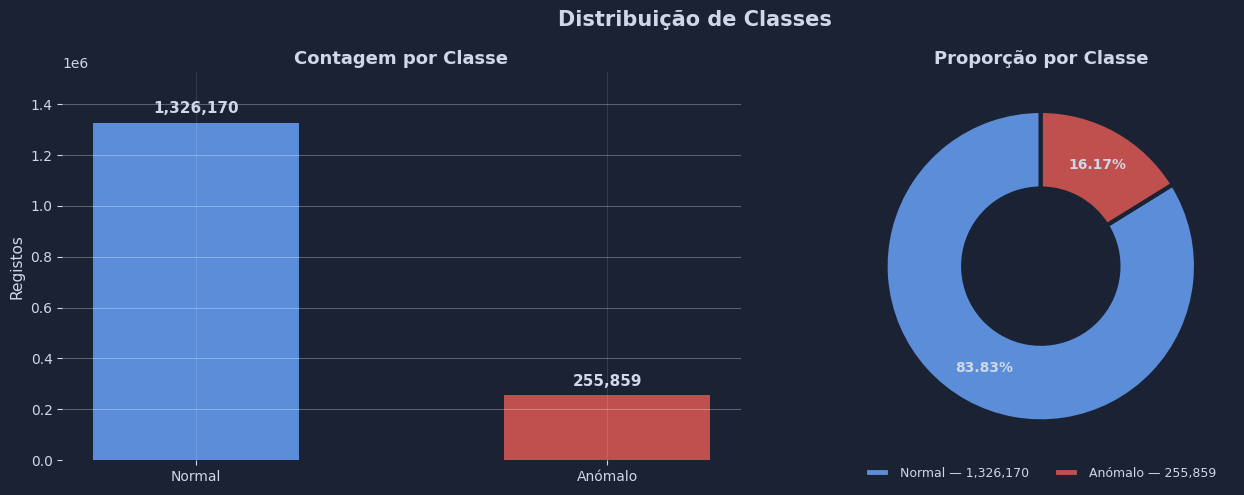

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de Classes')

contagens = df['label'].value_counts().sort_index()
labels_str = ['Normal', 'Anómalo']
cores = [BLUE, RED]

# Barplot
bars = axes[0].bar(labels_str, contagens.values, color=cores, width=0.5)
axes[0].set_title('Contagem por Classe')
axes[0].set_ylabel('Registos')
axes[0].set_xlabel('')
for bar, v in zip(bars, contagens.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + contagens.max()*0.02,
                 f'{v:,}', ha='center', va='bottom',
                 color=TEXT_COLOR, fontweight='bold', fontsize=11)
axes[0].set_ylim(0, contagens.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    contagens.values,
    colors=cores,
    autopct='%1.2f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': BG_COLOR, 'linewidth': 3, 'width': 0.5}
)
for t in autotexts:
    t.set_color(TEXT_COLOR)
    t.set_fontsize(10)
    t.set_fontweight('bold')
for t in texts:
    t.set_color(TEXT_COLOR)

axes[1].set_title('Proporção por Classe')
axes[1].legend(
    [f'Normal — {contagens[0]:,}', f'Anómalo — {contagens[1]:,}'],
    loc='lower center', bbox_to_anchor=(0.5, -0.08),
    ncol=2, fontsize=9, frameon=False
)

plt.tight_layout()
plt.show()

## 8. Distribuição das Features Numéricas (percentil 99)
Distribuição das primeiras 9 features de pseudo-labelling por classe (Normal vs Anómalo).
Os valores são truncados ao percentil 99 para remover o efeito de outliers extremos
e permitir uma visualização clara da distribuição central de cada feature.

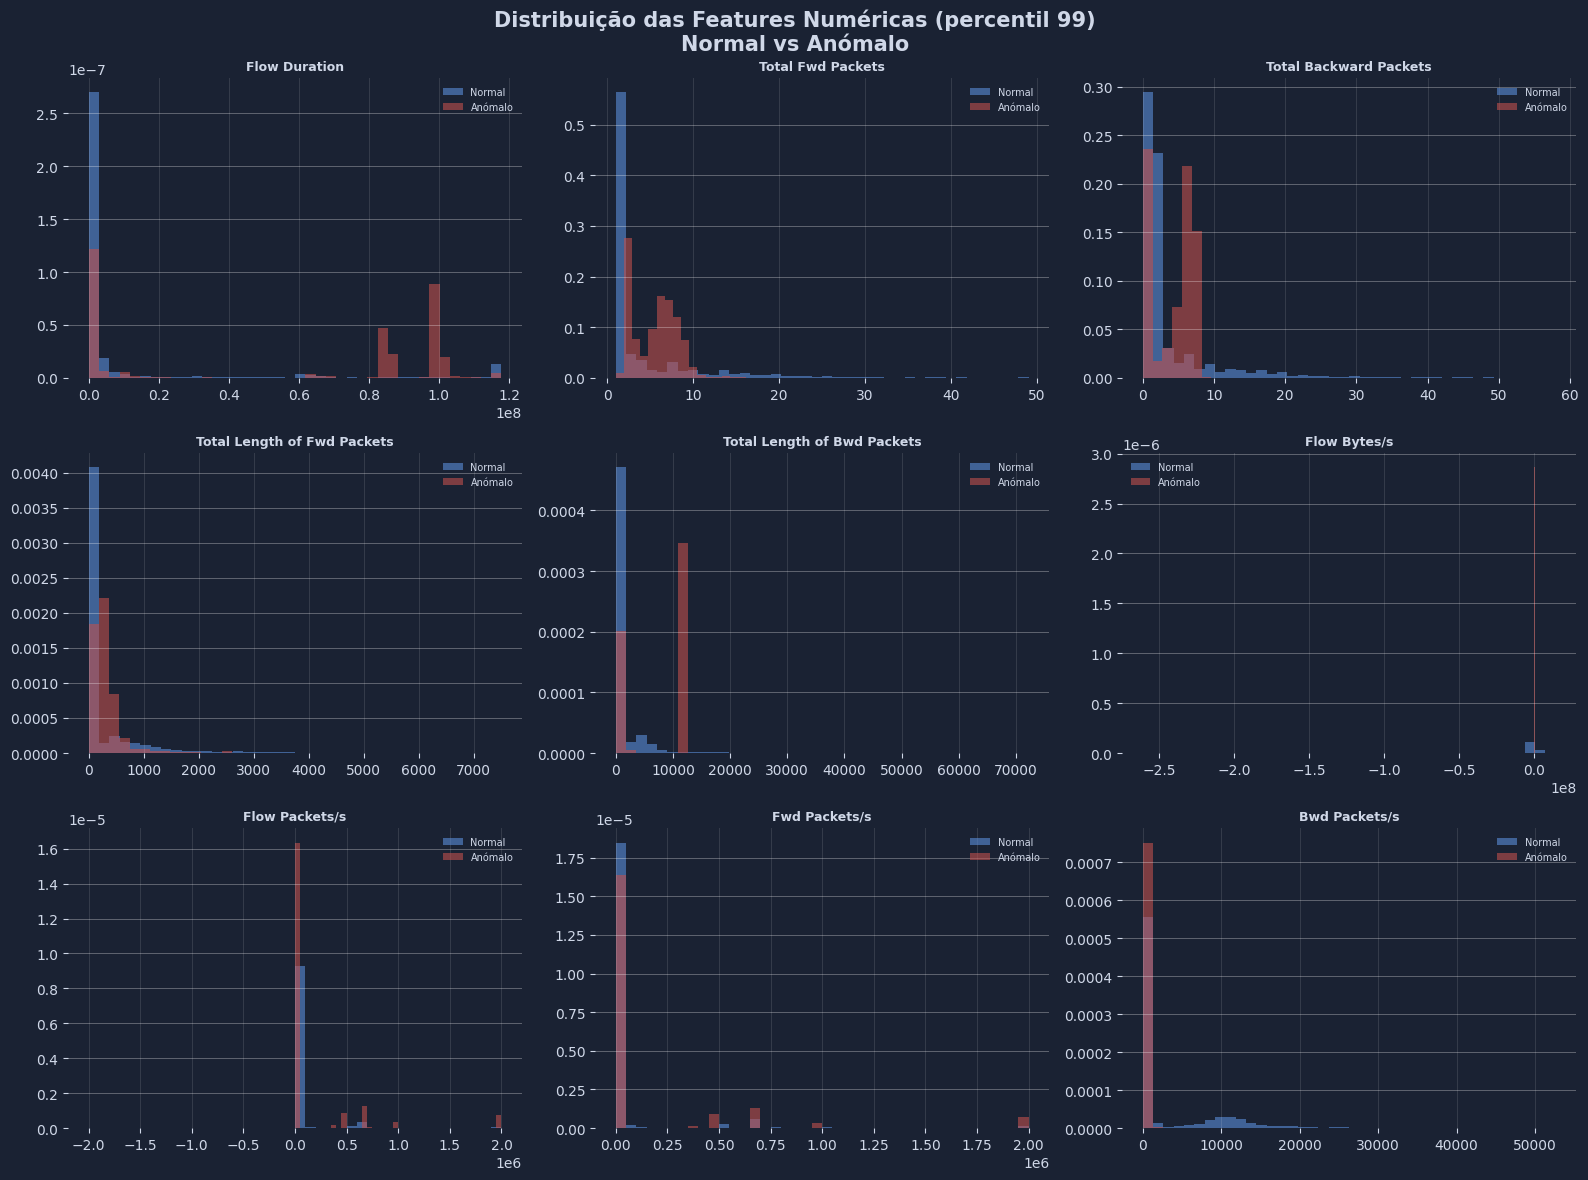

In [9]:
features_plot = features_pl[:9]  # primeiras 9 para visualização

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribuição das Features Numéricas (percentil 99)\nNormal vs Anómalo')
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    p99 = df[feat].quantile(0.99)
    dados = df[df[feat] <= p99]

    for classe, cor, nome in [(0, BLUE, 'Normal'), (1, RED, 'Anómalo')]:
        subset = dados[dados['label'] == classe][feat]
        axes[i].hist(subset, bins=40, color=cor, alpha=0.6,
                     label=nome, density=True, edgecolor='none')

    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 9. Matriz de Correlação
Visualização das correlações entre as features do modelo supervisionado.
Permite identificar features redundantes e relações lineares entre variáveis.

In [10]:
corr = df[features_modelo].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=corr.columns.tolist(),
    y=corr.columns.tolist(),
    colorscale='RdBu_r',
    zmid=0,
    zmin=-1, zmax=1,
    hoverongaps=False,
    hovertemplate='<b>%{y}</b> × <b>%{x}</b><br>Correlação: %{z:.3f}<extra></extra>',
    colorbar=dict(
        title=dict(
            text='Correlação',
            font=dict(color=TEXT_COLOR, size=13)
        ),
        tickfont=dict(color=TEXT_COLOR, size=11),
        bgcolor=BG_COLOR,
        bordercolor=GRID_COLOR,
    )
))

fig.update_layout(
    title=dict(
        text='Matriz de Correlação — Features do Modelo<br><sup>Vermelho escuro = correlação forte  |  Branco = correlação fraca</sup>',
        font=dict(color=TEXT_COLOR, size=22),
        x=0.5,
        xanchor='center'
    ),
    paper_bgcolor=BG_COLOR,
    plot_bgcolor=BG_COLOR,
    font=dict(color=TEXT_COLOR, size=7),
    width=1800,
    height=1700,
    xaxis=dict(
        tickangle=45,
        tickfont=dict(size=11, color=TEXT_COLOR),
        gridcolor=GRID_COLOR,
        autorange='reversed'
    ),
    yaxis=dict(
        tickfont=dict(size=11, color=TEXT_COLOR),
        gridcolor=GRID_COLOR,
        autorange='reversed'
    )
)

fig.show()

## 10. Boxplots por Classe
Distribuição das features de pseudo-labelling por classe (Normal vs Anómalo).
Permite identificar diferenças na distribuição e outliers entre as duas classes.

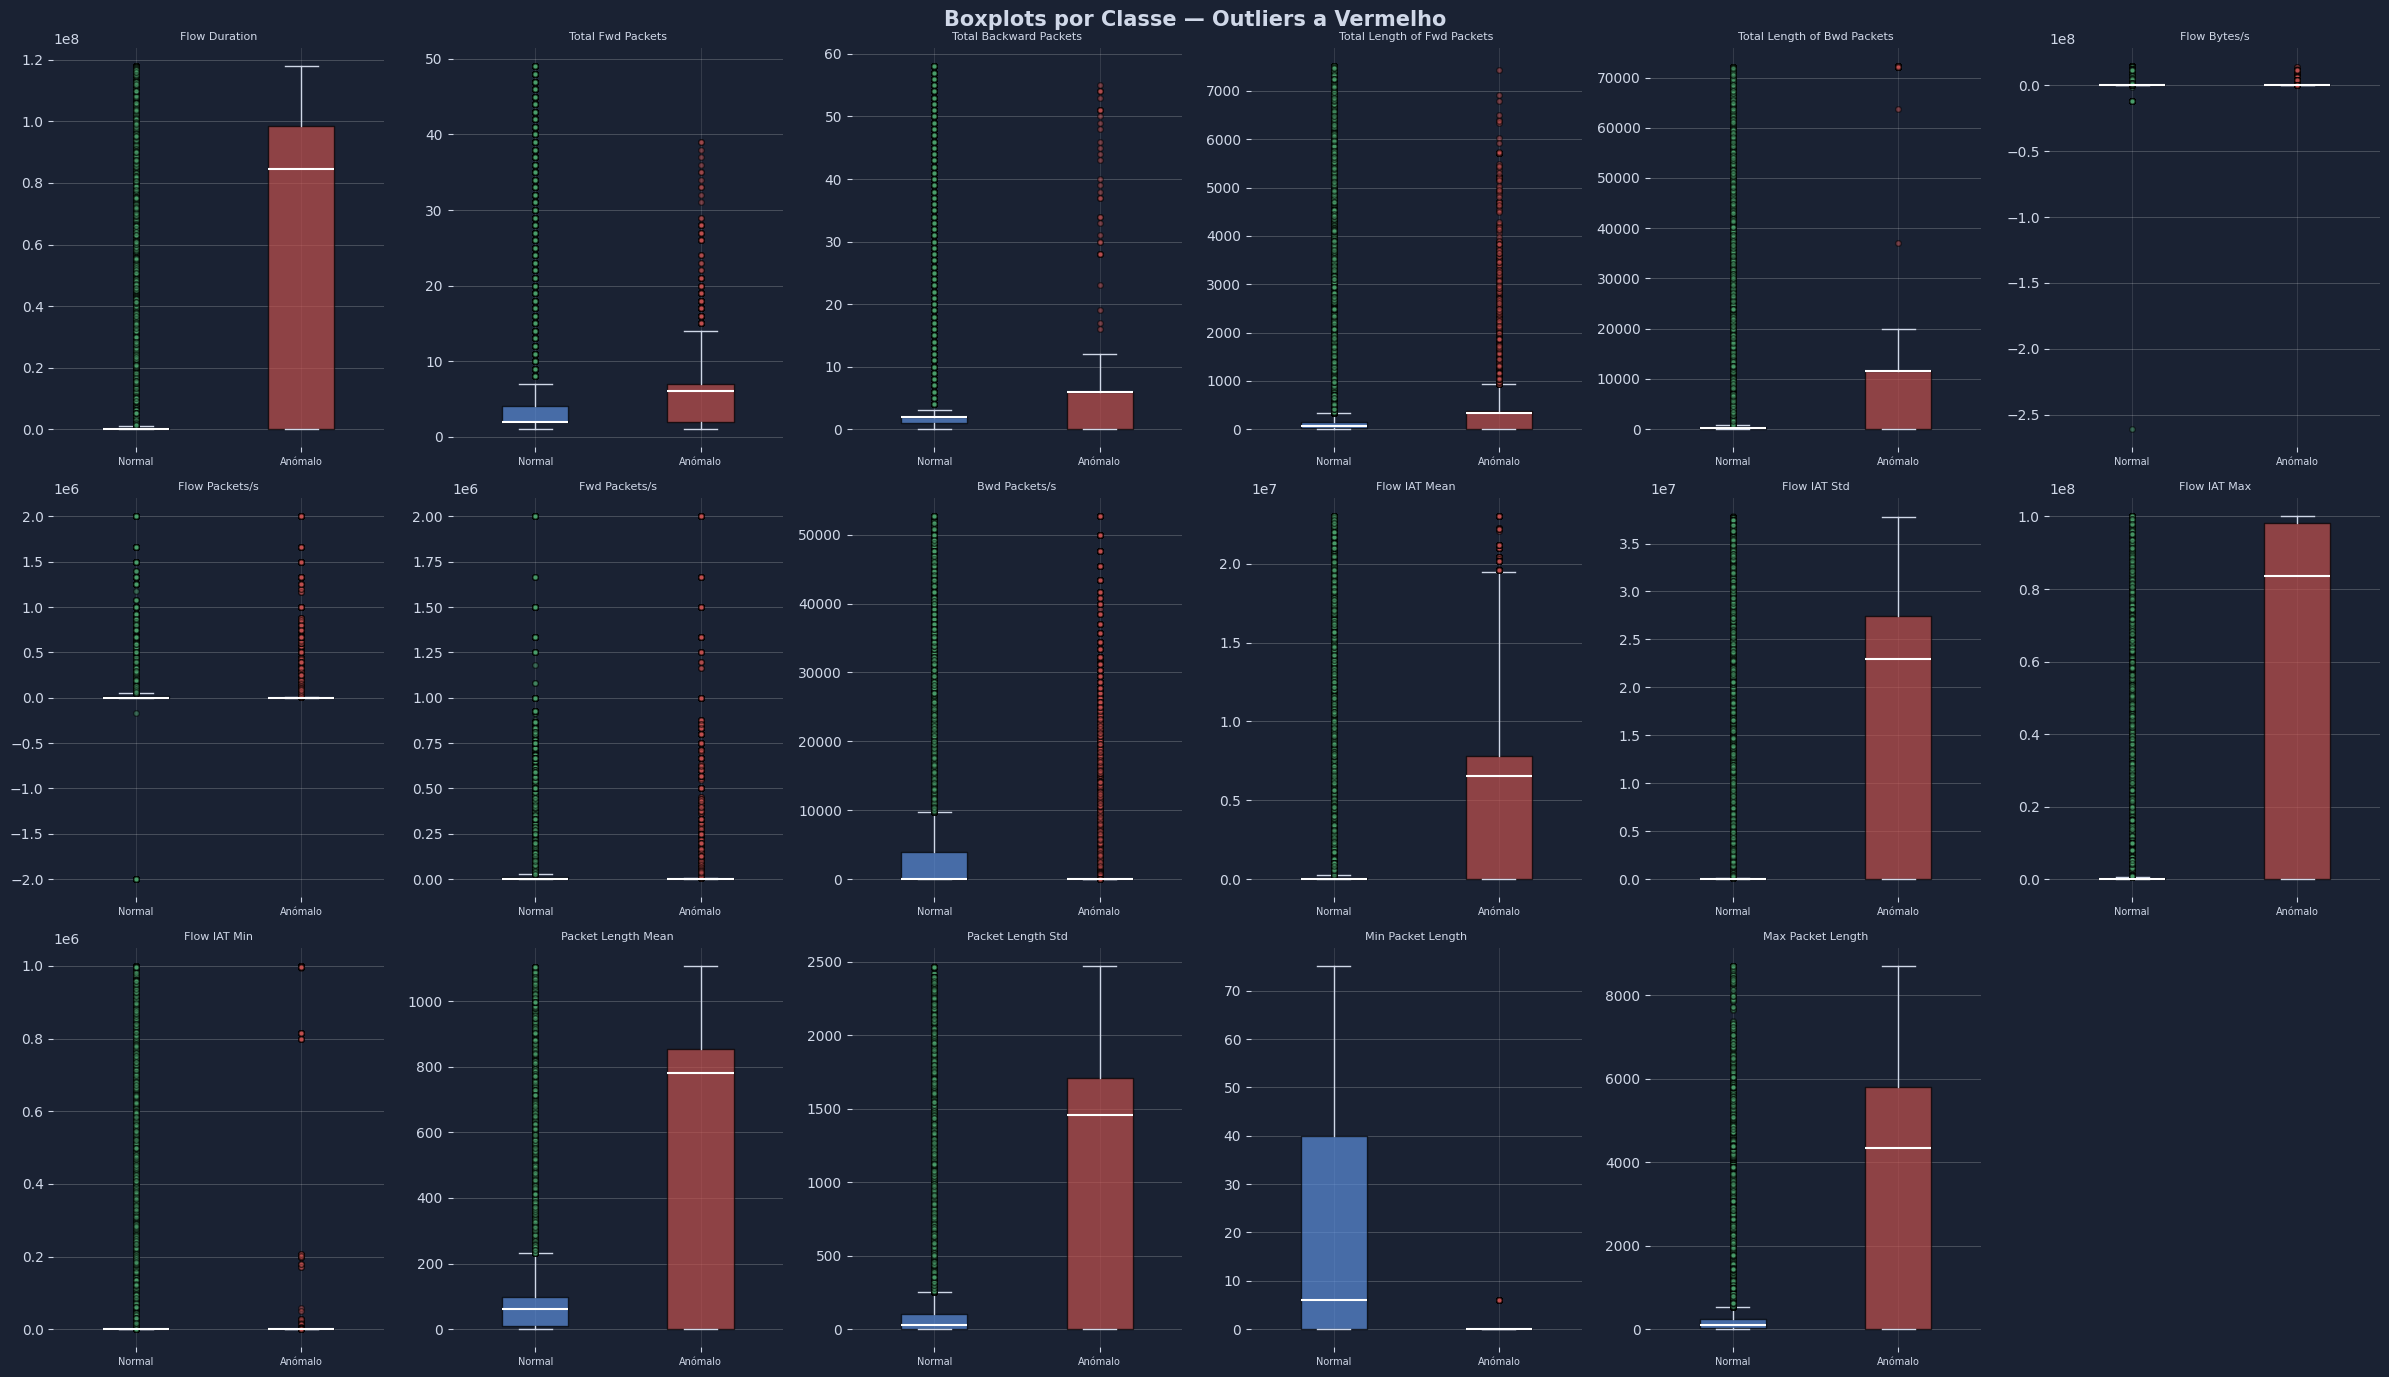

In [11]:
fig, axes = plt.subplots(3, 6, figsize=(24, 14))
fig.suptitle('Boxplots por Classe — Outliers a Vermelho')
axes = axes.flatten()

for i, feat in enumerate(features_pl):
    p99 = df[feat].quantile(0.99)
    dados = df[df[feat] <= p99]

    normal = dados[dados['label'] == 0][feat]
    anomalo = dados[dados['label'] == 1][feat]

    bp0 = axes[i].boxplot(normal, positions=[0], widths=0.4,
                          patch_artist=True,
                          flierprops=dict(marker='o', color='#4a9e6b', markerfacecolor='#4a9e6b', markersize=4, alpha=0.5, linestyle='none'),
                          medianprops=dict(color='white', linewidth=1.5),
                          boxprops=dict(facecolor=BLUE, alpha=0.7),
                          whiskerprops=dict(color=TEXT_COLOR),
                          capprops=dict(color=TEXT_COLOR))

    bp1 = axes[i].boxplot(anomalo, positions=[1], widths=0.4,
                          patch_artist=True,
                          flierprops=dict(marker='o', color='#c05050', markerfacecolor='#c05050', markersize=4, alpha=0.5, linestyle='none'),
                          medianprops=dict(color='white', linewidth=1.5),
                          boxprops=dict(facecolor=RED, alpha=0.7),
                          whiskerprops=dict(color=TEXT_COLOR),
                          capprops=dict(color=TEXT_COLOR))

    axes[i].set_title(feat, fontsize=8, fontweight='normal')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal', 'Anómalo'], fontsize=7)
    axes[i].grid(axis='y', alpha=0.2)

# Remover subplots vazios
for j in range(len(features_pl), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 11. Violin Plot por Classe
Distribuição das features de pseudo-labelling por classe com densidade de probabilidade.
A linha branca representa a mediana de cada distribuição.

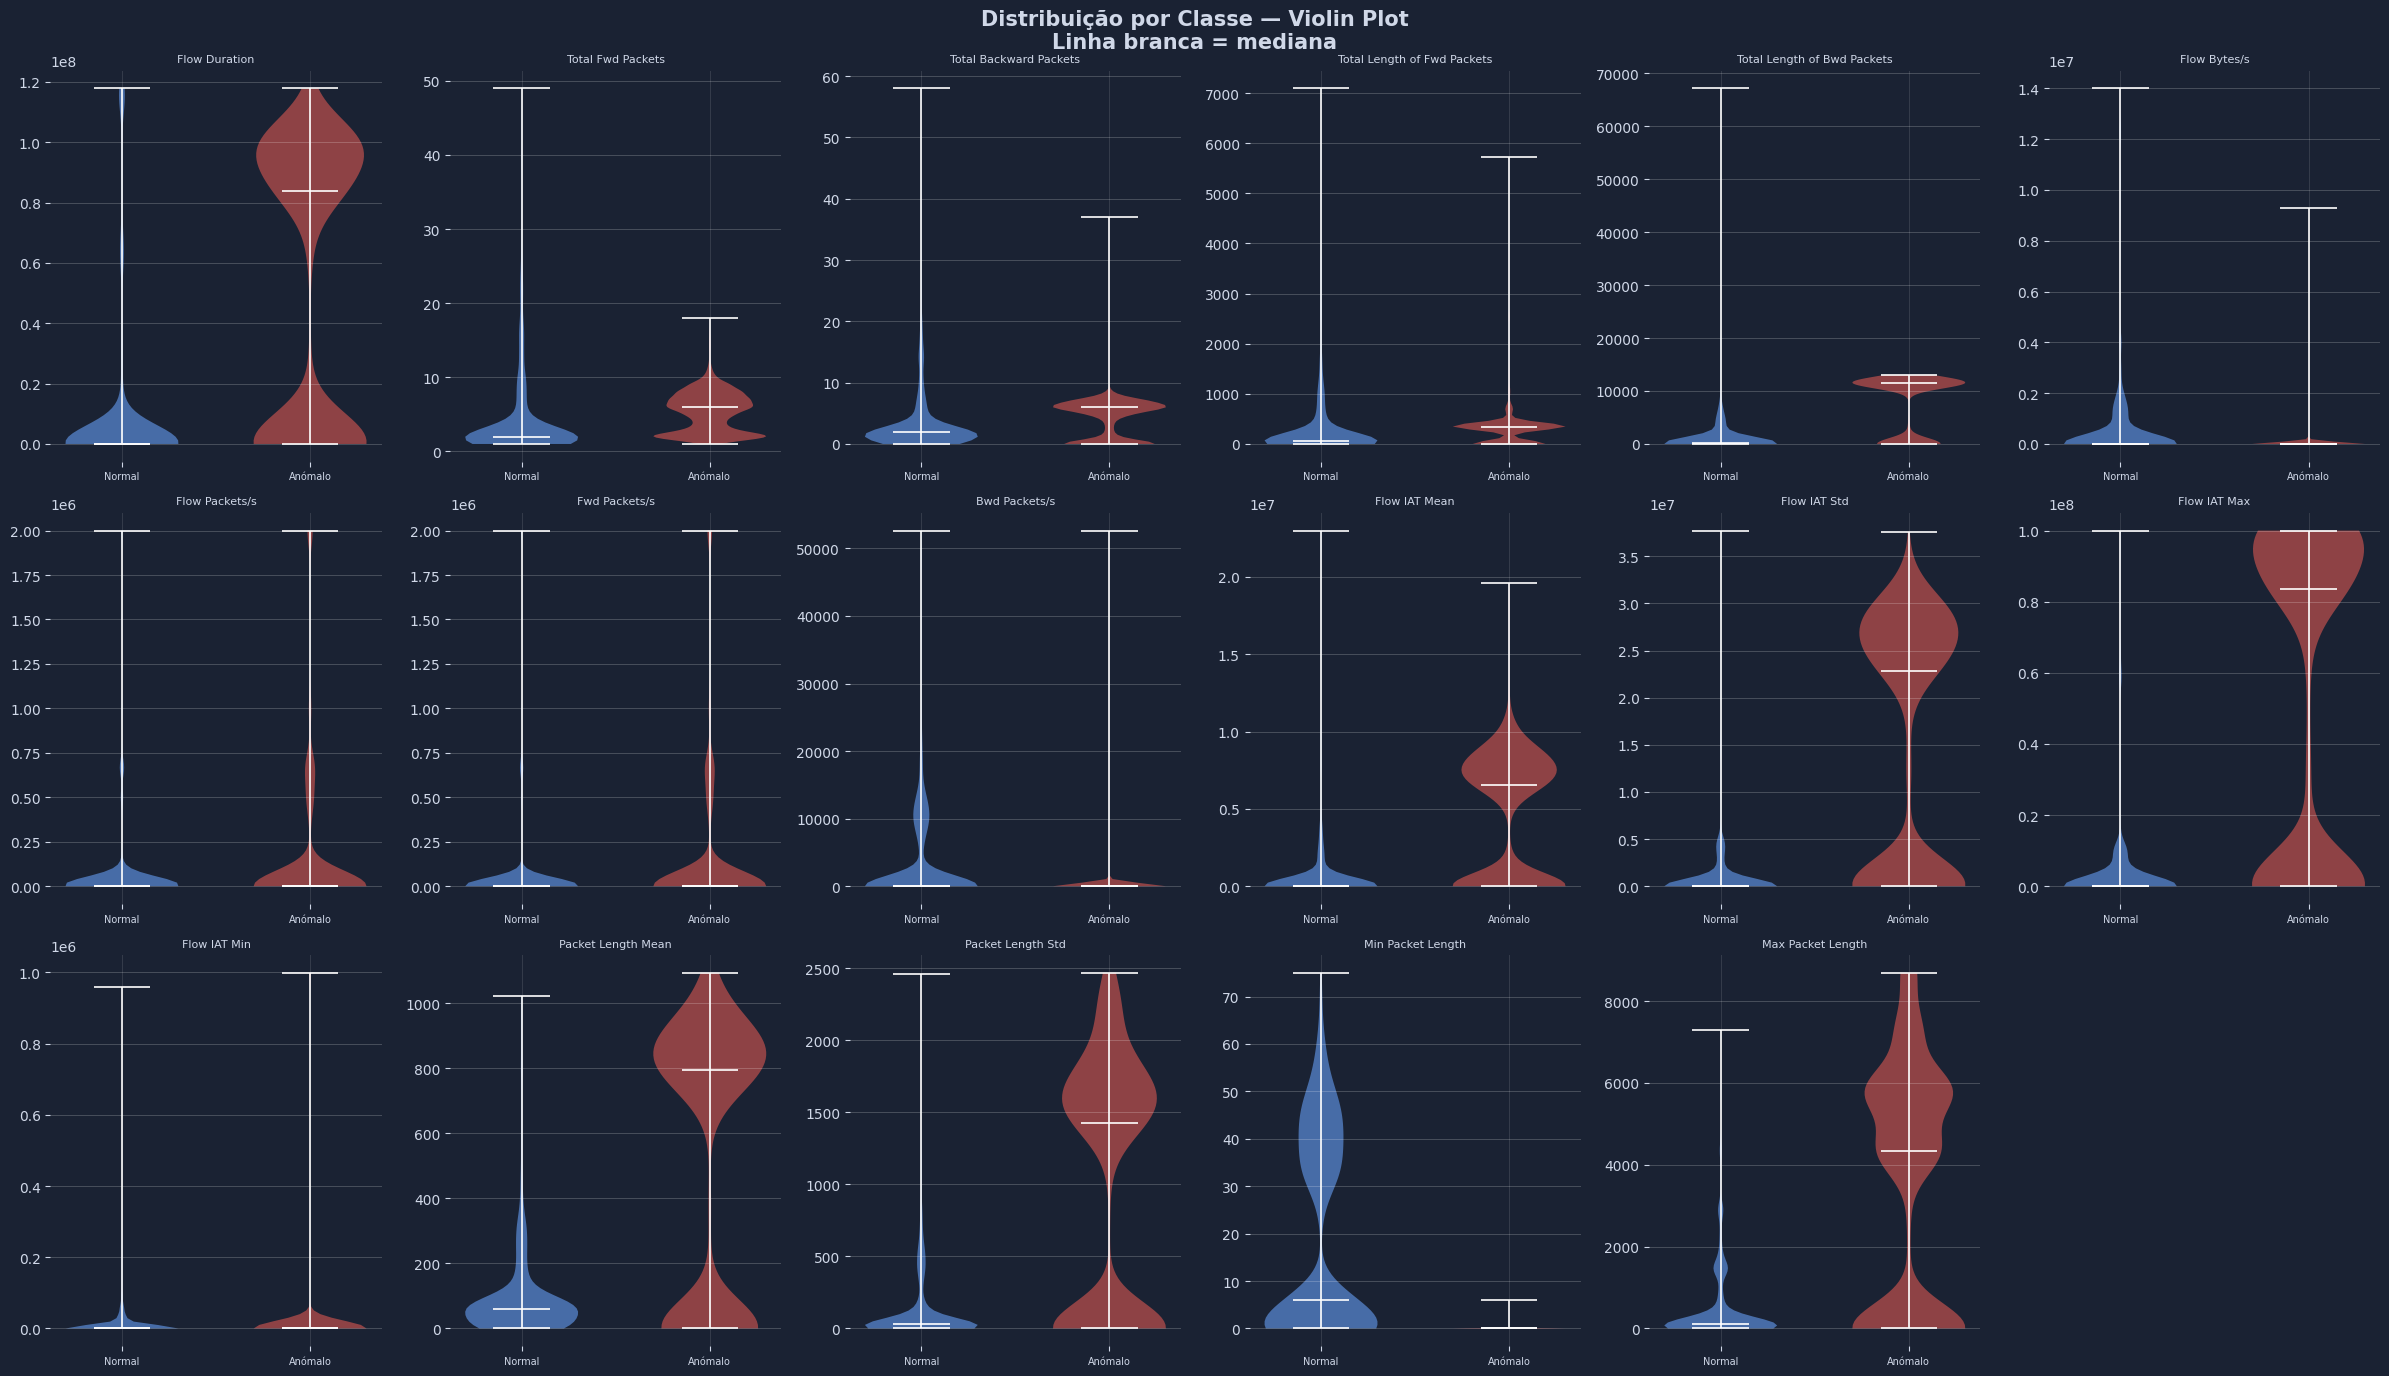

In [12]:
fig, axes = plt.subplots(3, 6, figsize=(24, 14))
fig.suptitle('Distribuição por Classe — Violin Plot\nLinha branca = mediana')
axes = axes.flatten()

for i, feat in enumerate(features_pl):
    p99 = df[feat].quantile(0.99)
    dados = df[df[feat] <= p99]

    normal = dados[dados['label'] == 0][feat].sample(min(3000, len(dados[dados['label'] == 0])), random_state=42)
    anomalo = dados[dados['label'] == 1][feat].sample(min(3000, len(dados[dados['label'] == 1])), random_state=42)

    parts0 = axes[i].violinplot(normal, positions=[0], widths=0.6, showmedians=True)
    parts1 = axes[i].violinplot(anomalo, positions=[1], widths=0.6, showmedians=True)

    for pc in parts0['bodies']:
        pc.set_facecolor(BLUE)
        pc.set_alpha(0.7)
    for part in ['cmedians', 'cbars', 'cmaxes', 'cmins']:
        parts0[part].set_color('white')
        parts0[part].set_linewidth(1.2)

    for pc in parts1['bodies']:
        pc.set_facecolor(RED)
        pc.set_alpha(0.7)
    for part in ['cmedians', 'cbars', 'cmaxes', 'cmins']:
        parts1[part].set_color('white')
        parts1[part].set_linewidth(1.2)

    axes[i].set_title(feat, fontsize=8, fontweight='normal')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal', 'Anómalo'], fontsize=7)
    axes[i].grid(axis='y', alpha=0.2)

for j in range(len(features_pl), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 12. Bytes Recebidos vs Enviados — Distribuições Marginais
Relação entre o volume de pacotes enviados e recebidos por classe.
As distribuições marginais mostram a densidade de cada variável individualmente.

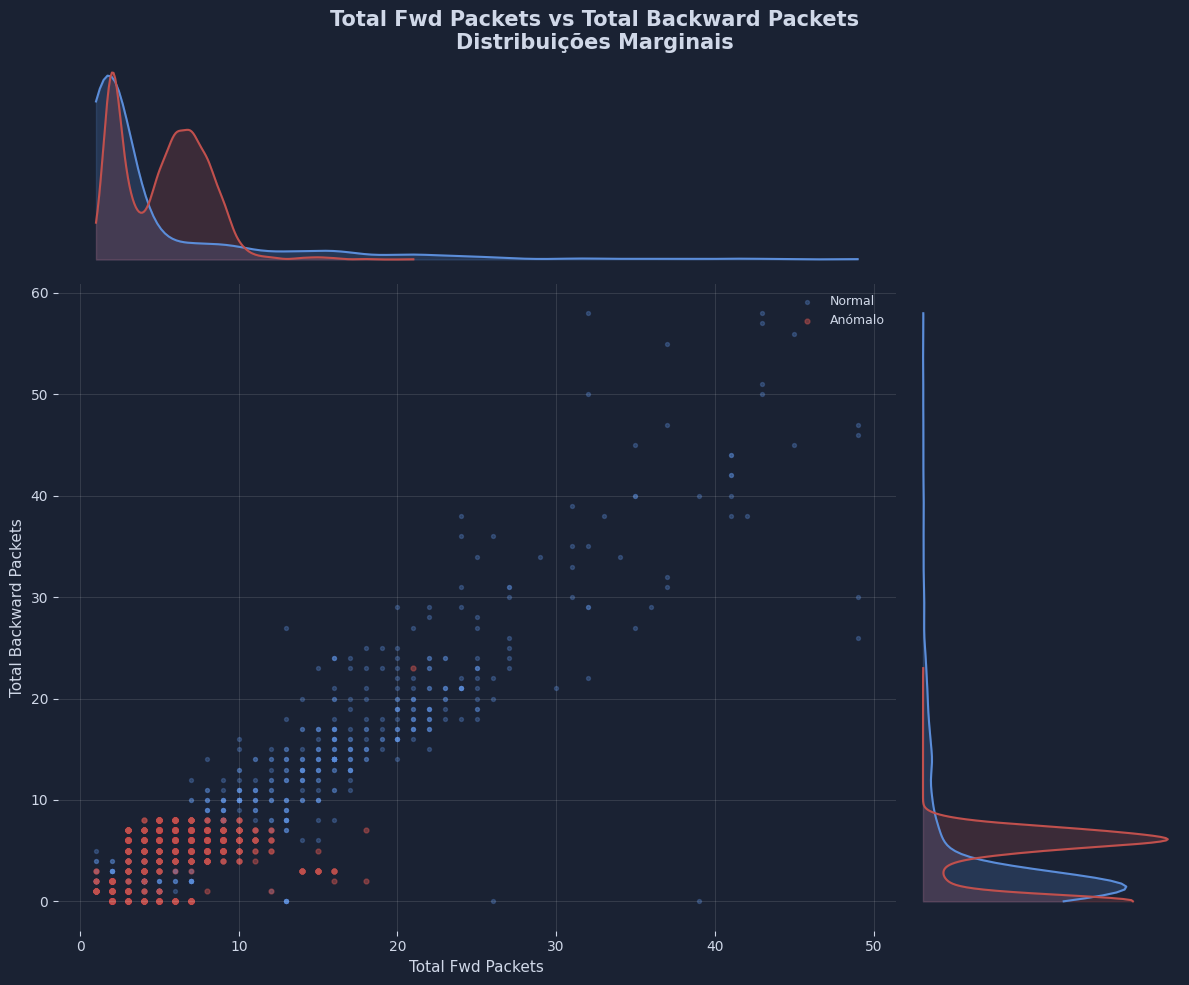

In [ ]:
p99_x = df['Total Fwd Packets'].quantile(0.99)
p99_y = df['Total Backward Packets'].quantile(0.99)

dados = df[(df['Total Fwd Packets'] <= p99_x) & (df['Total Backward Packets'] <= p99_y)]
normal = dados[dados['label'] == 0].sample(min(3000, len(dados[dados['label'] == 0])), random_state=42)
anomalo = dados[dados['label'] == 1].sample(min(3000, len(dados[dados['label'] == 1])), random_state=42)

fig = plt.figure(figsize=(12, 10))
fig.suptitle('Total Fwd Packets vs Total Backward Packets\nDistribuições Marginais')

gs = GridSpec(4, 4, figure=fig)
ax_main  = fig.add_subplot(gs[1:4, 0:3])
ax_top   = fig.add_subplot(gs[0, 0:3])
ax_right = fig.add_subplot(gs[1:4, 3])

# Scatter principal
ax_main.scatter(normal['Total Fwd Packets'], normal['Total Backward Packets'],
                color=BLUE, alpha=0.3, s=8, label='Normal')
ax_main.scatter(anomalo['Total Fwd Packets'], anomalo['Total Backward Packets'],
                color=RED, alpha=0.5, s=12, label='Anómalo')
ax_main.set_xlabel('Total Fwd Packets')
ax_main.set_ylabel('Total Backward Packets')
ax_main.legend(fontsize=9)

# KDE marginal superior
for dados_cls, cor in [(normal, BLUE), (anomalo, RED)]:
    kde = stats.gaussian_kde(dados_cls['Total Fwd Packets'])
    x_range = np.linspace(dados_cls['Total Fwd Packets'].min(),
                          dados_cls['Total Fwd Packets'].max(), 200)
    ax_top.plot(x_range, kde(x_range), color=cor, linewidth=1.5)
    ax_top.fill_between(x_range, kde(x_range), alpha=0.2, color=cor)
ax_top.set_xlim(ax_main.get_xlim())
ax_top.axis('off')

# KDE marginal direita
for dados_cls, cor in [(normal, BLUE), (anomalo, RED)]:
    kde = stats.gaussian_kde(dados_cls['Total Backward Packets'])
    y_range = np.linspace(dados_cls['Total Backward Packets'].min(),
                          dados_cls['Total Backward Packets'].max(), 200)
    ax_right.plot(kde(y_range), y_range, color=cor, linewidth=1.5)
    ax_right.fill_betweenx(y_range, kde(y_range), alpha=0.2, color=cor)
ax_right.set_ylim(ax_main.get_ylim())
ax_right.axis('off')

plt.tight_layout()
plt.show()

## 13. Matriz de Dispersão — Features Principais
Relação entre as principais features de pseudo-labelling por classe.
A diagonal mostra a distribuição de densidade (KDE) de cada feature.

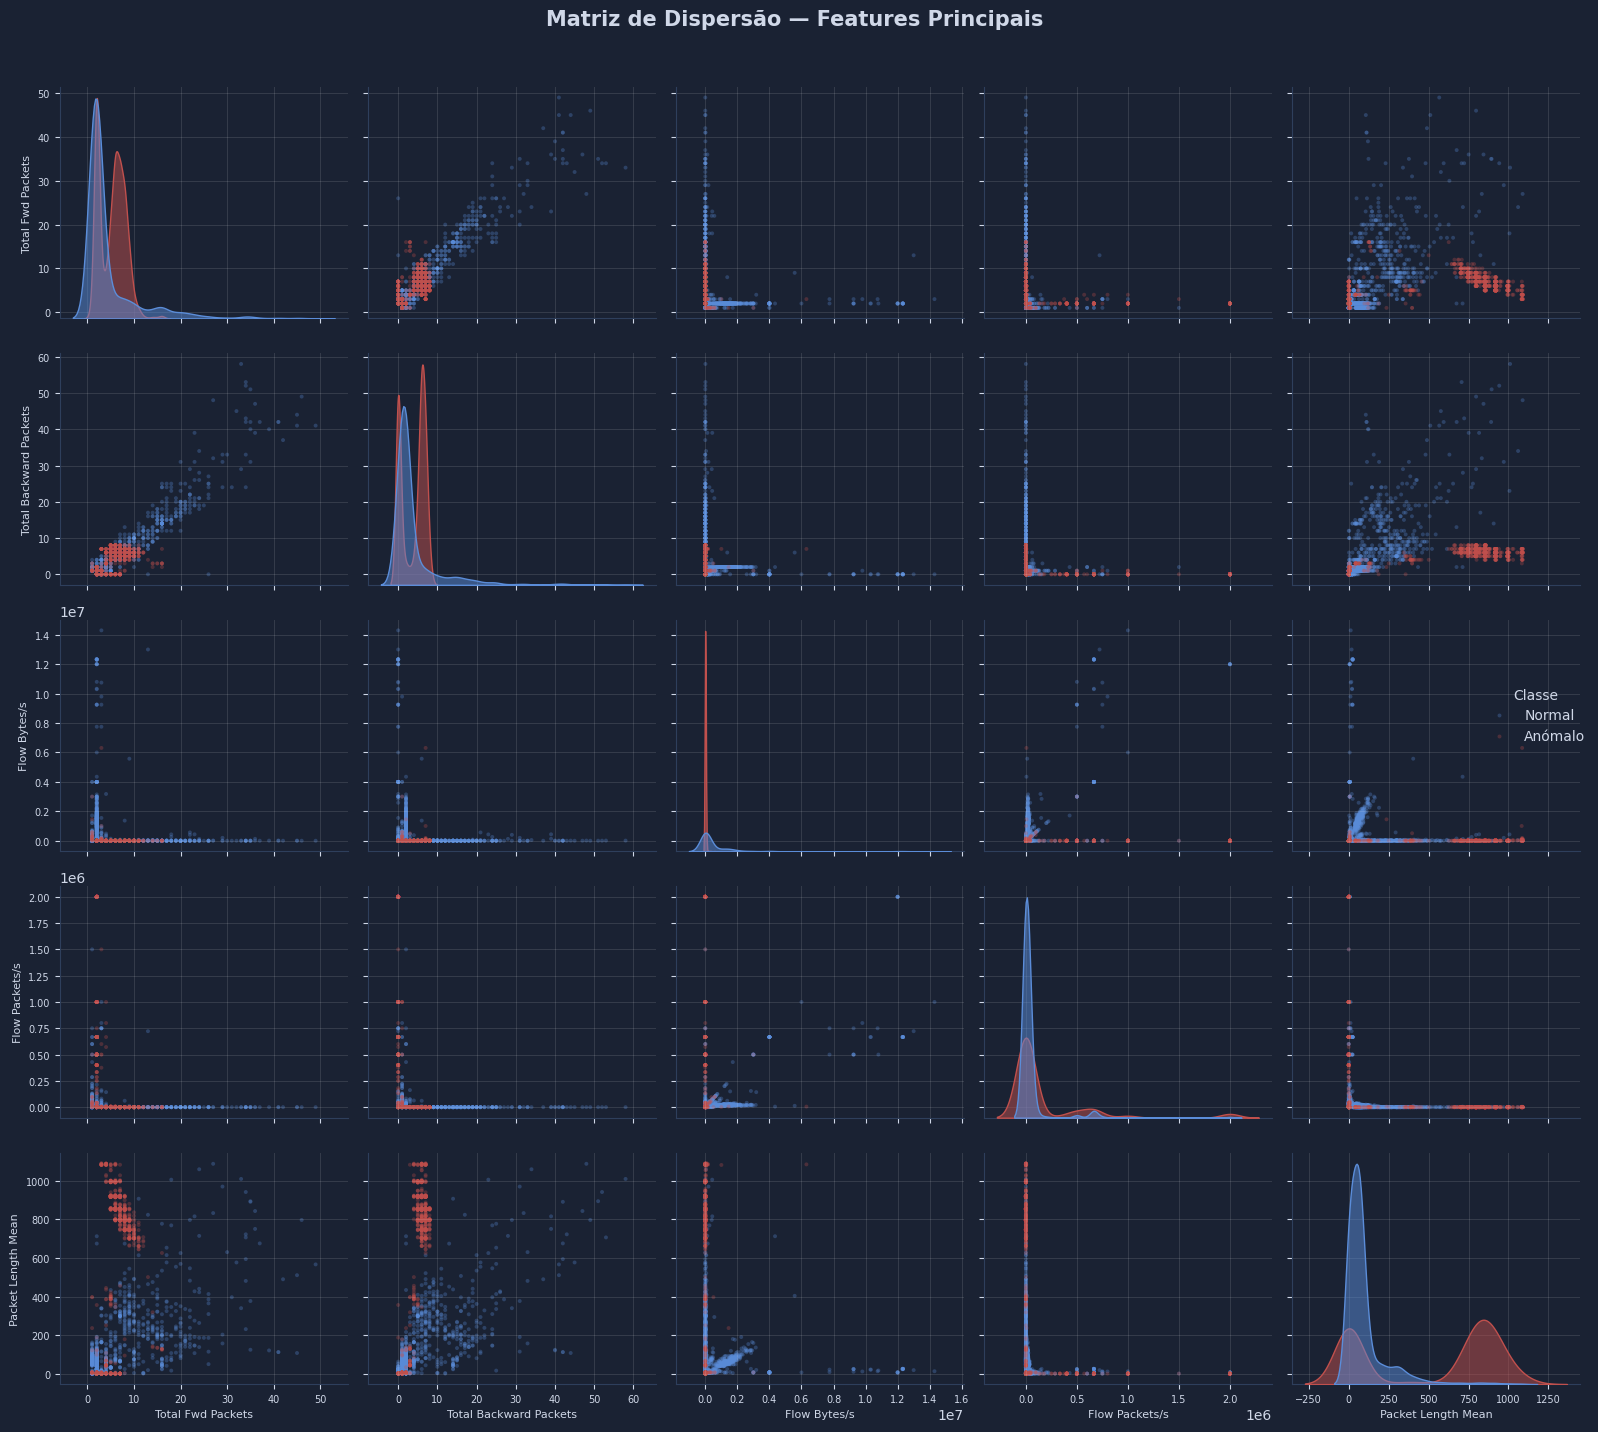

In [14]:
features_pairplot = [
    'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean'
]

p99 = df[features_pairplot].quantile(0.99)
dados_pp = df[(df[features_pairplot] <= p99).all(axis=1)].copy()
dados_pp['Classe'] = dados_pp['label'].map({0: 'Normal', 1: 'Anómalo'})

sample_normal  = dados_pp[dados_pp['Classe'] == 'Normal'].sample(2000, random_state=42)
sample_anomalo = dados_pp[dados_pp['Classe'] == 'Anómalo'].sample(min(2000, len(dados_pp[dados_pp['Classe'] == 'Anómalo'])), random_state=42)
dados_sample = pd.concat([sample_normal, sample_anomalo])

g = sns.pairplot(
    dados_sample,
    vars=features_pairplot,
    hue='Classe',
    palette={'Normal': BLUE, 'Anómalo': RED},
    plot_kws=dict(alpha=0.3, s=8, edgecolor='none'),
    diag_kws=dict(fill=True, alpha=0.5),
    diag_kind='kde',
    corner=False
)

g.figure.suptitle('Matriz de Dispersão — Features Principais', y=1.02)
g.figure.set_size_inches(16, 14)

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(BG_COLOR)
        ax.figure.set_facecolor(BG_COLOR)
        ax.tick_params(colors=TEXT_COLOR, labelsize=7)
        ax.xaxis.label.set_color(TEXT_COLOR)
        ax.yaxis.label.set_color(TEXT_COLOR)
        ax.xaxis.label.set_size(8)
        ax.yaxis.label.set_size(8)

g._legend.set_title('Classe')
plt.setp(g._legend.get_texts(), color=TEXT_COLOR)
plt.setp(g._legend.get_title(), color=TEXT_COLOR)
g._legend.get_frame().set_facecolor(BG_COLOR)
g._legend.get_frame().set_edgecolor(GRID_COLOR)

plt.tight_layout()
plt.show()

## 14. Distribuição Acumulada (CDF) por Classe
Comparação da distribuição acumulada das features entre tráfego Normal e Anómalo.
Diferenças pronunciadas entre as curvas indicam features com maior poder discriminativo.

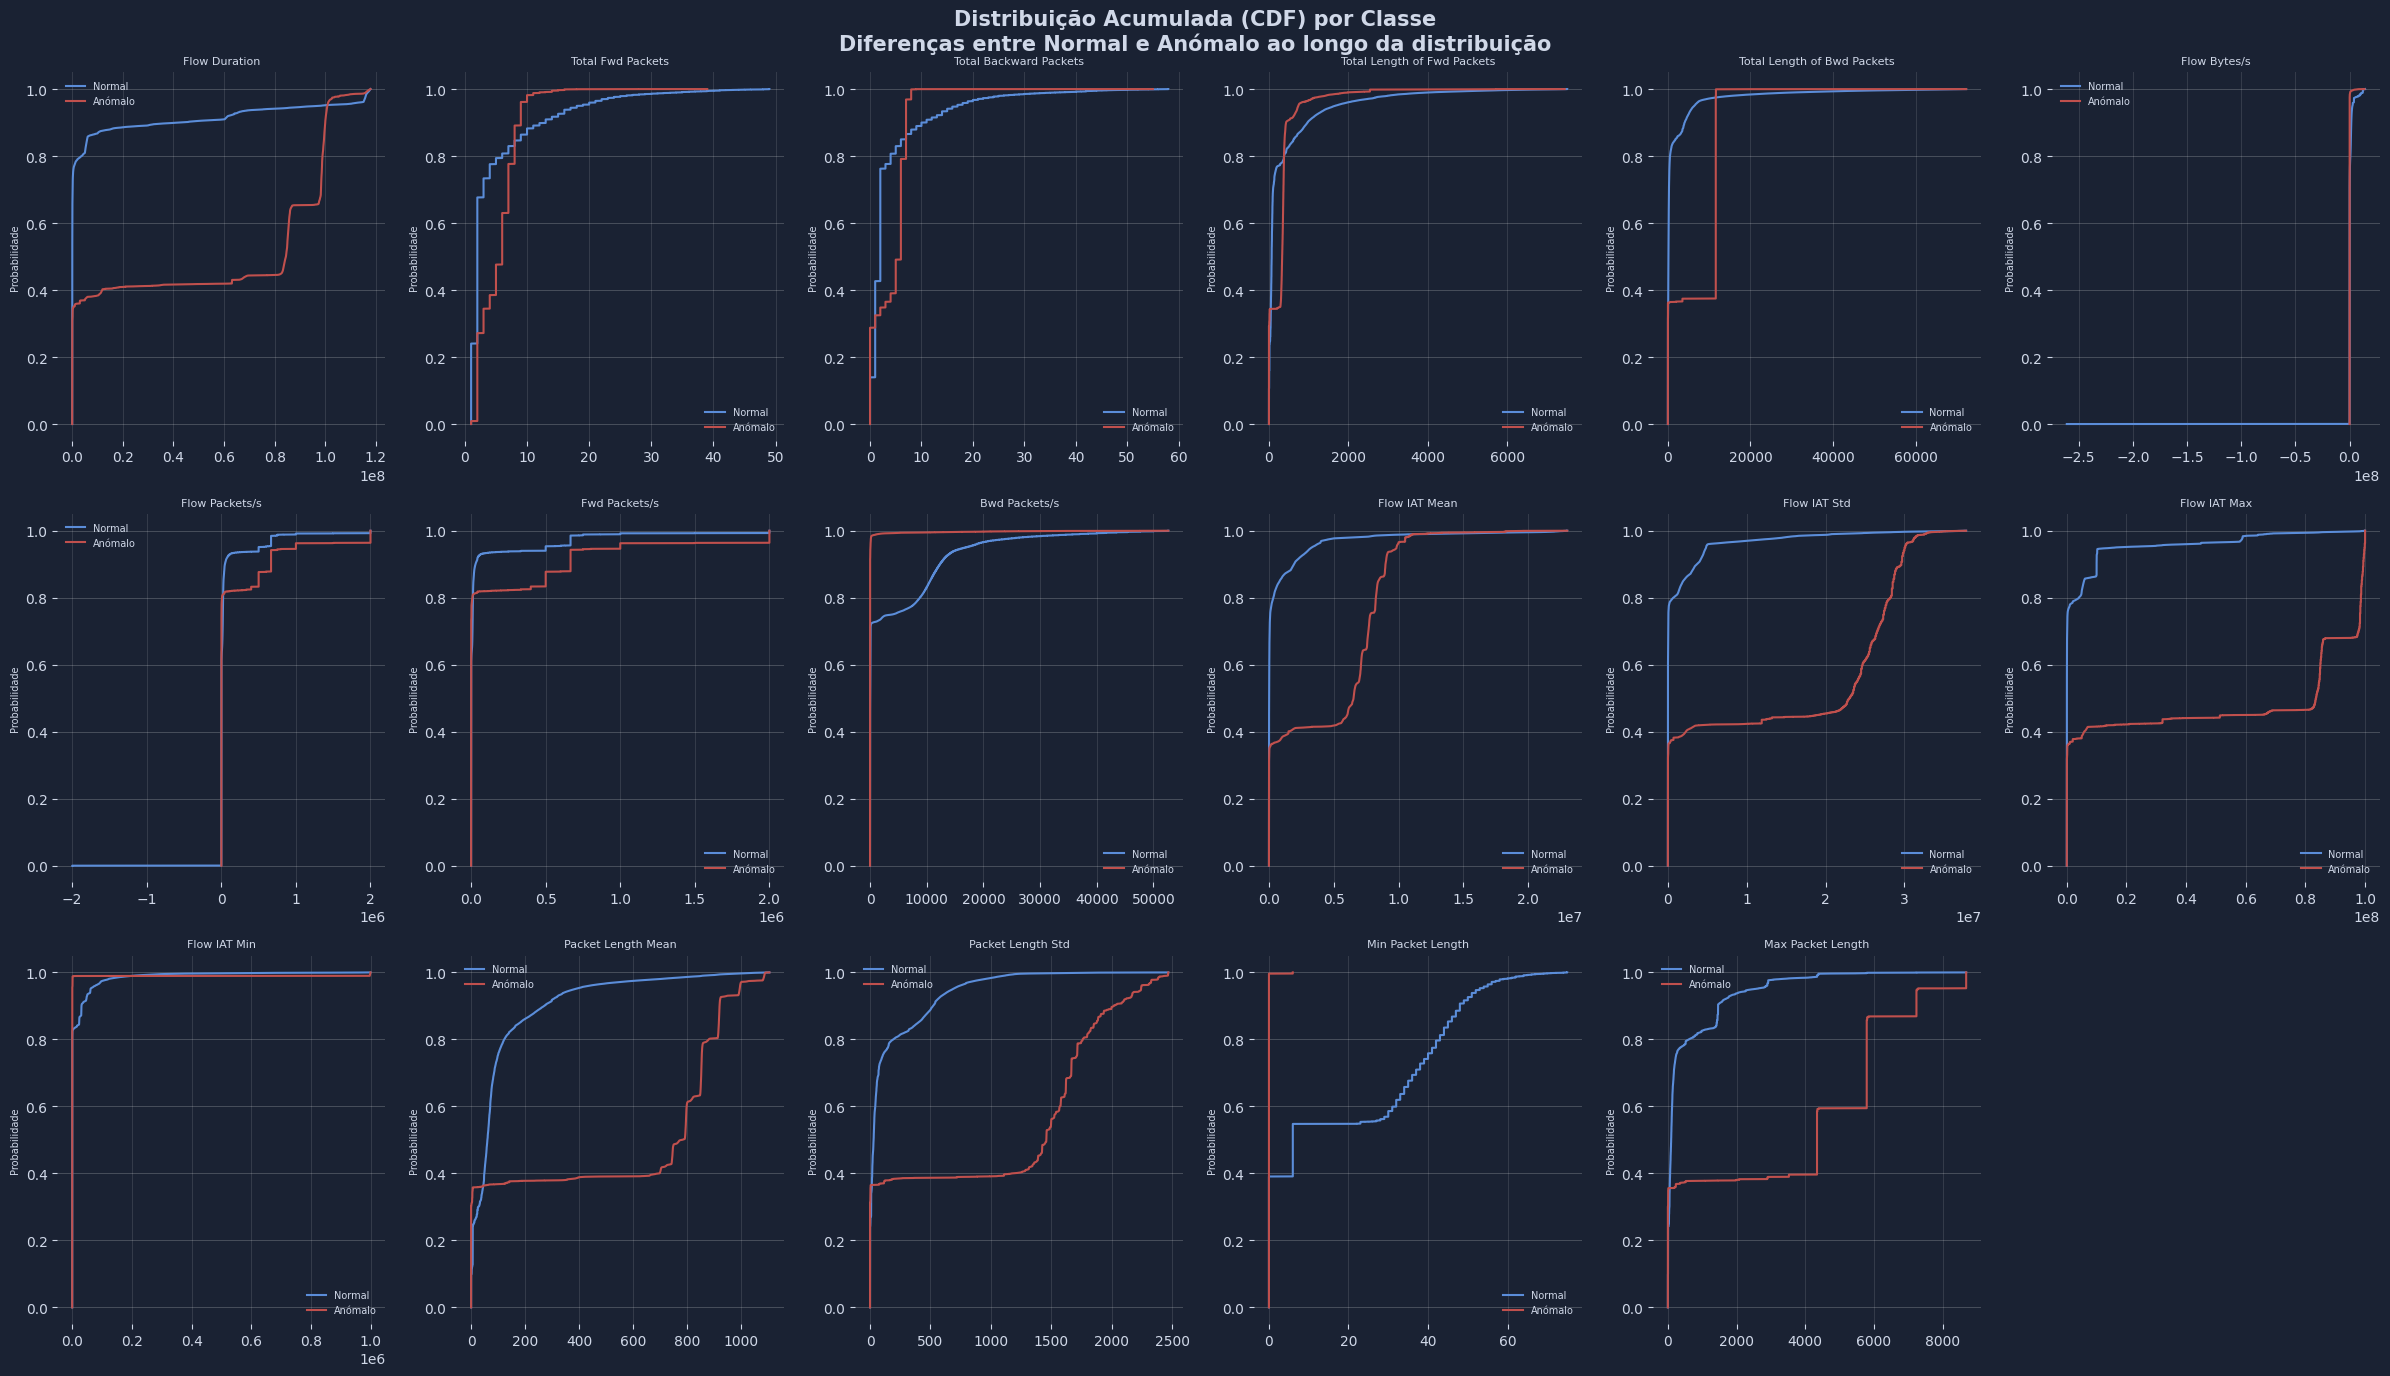

In [15]:
fig, axes = plt.subplots(3, 6, figsize=(24, 14))
fig.suptitle('Distribuição Acumulada (CDF) por Classe\nDiferenças entre Normal e Anómalo ao longo da distribuição')
axes = axes.flatten()

for i, feat in enumerate(features_pl):
    p99 = df[feat].quantile(0.99)
    dados = df[df[feat] <= p99]

    for classe, cor, nome in [(0, BLUE, 'Normal'), (1, RED, 'Anómalo')]:
        subset = dados[dados['label'] == classe][feat].dropna()
        subset_sorted = np.sort(subset)
        cdf = np.arange(1, len(subset_sorted) + 1) / len(subset_sorted)
        axes[i].plot(subset_sorted, cdf, color=cor, linewidth=1.5, label=nome)

    axes[i].set_title(feat, fontsize=8, fontweight='normal')
    axes[i].set_ylabel('Probabilidade', fontsize=7)
    axes[i].legend(fontsize=7)
    axes[i].grid(axis='y', alpha=0.2)

for j in range(len(features_pl), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 15. Distribuição de Tráfego por Dia de Captura
Análise da distribuição de tráfego normal e anómalo por dia de captura.
Permite contextualizar o volume e proporção de ataques em cada sessão do dataset.

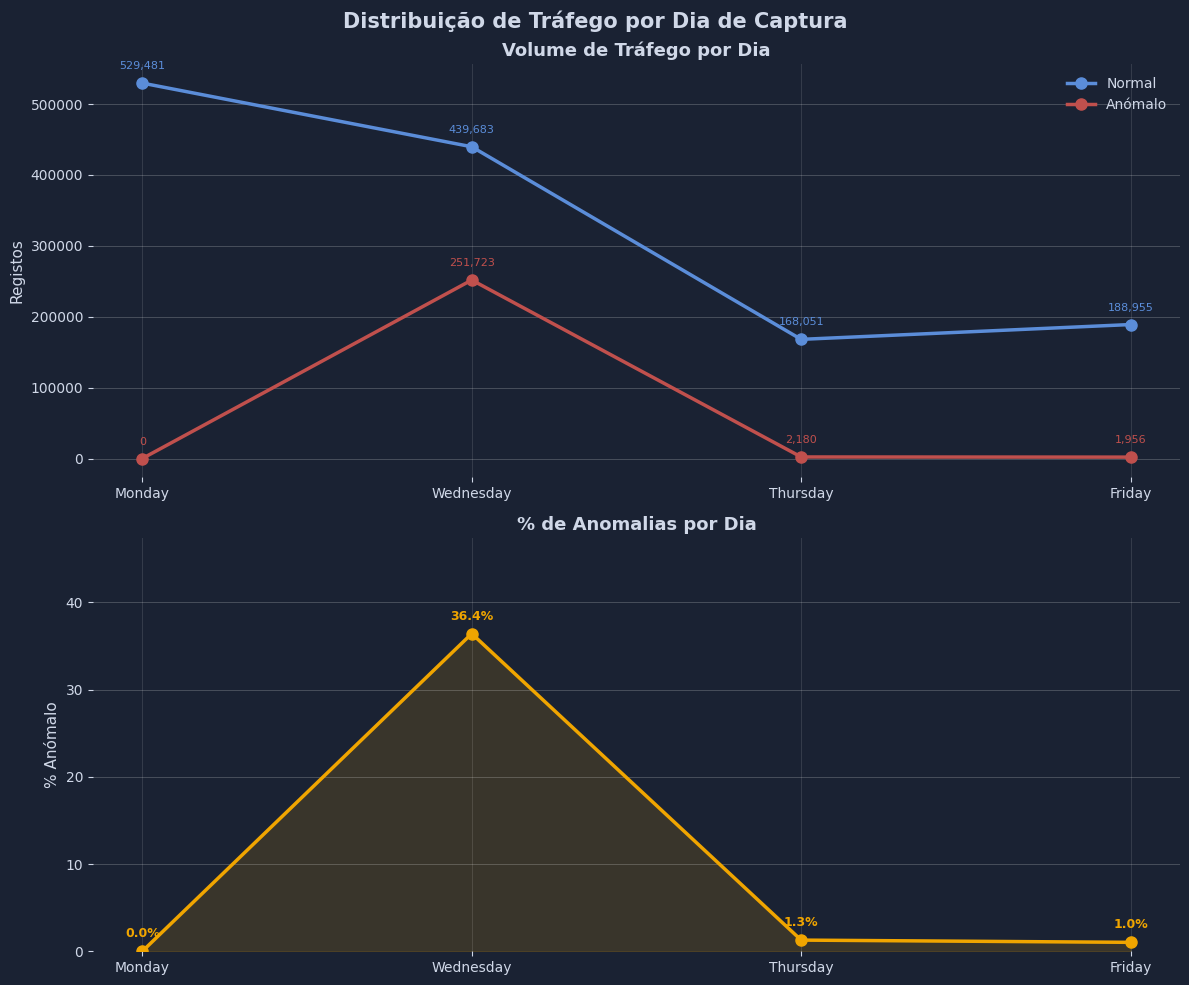

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Distribuição de Tráfego por Dia de Captura')

ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']

contagens = df.groupby(['day', 'label']).size().unstack(fill_value=0)
contagens = contagens.reindex(ordem_dias)
contagens.columns = ['Normal', 'Anómalo']

# Gráfico de linhas — contagem absoluta
axes[0].plot(ordem_dias, contagens['Normal'], color=BLUE, linewidth=2.5,
             marker='o', markersize=8, label='Normal')
axes[0].plot(ordem_dias, contagens['Anómalo'], color=RED, linewidth=2.5,
             marker='o', markersize=8, label='Anómalo')

for i, dia in enumerate(ordem_dias):
    axes[0].annotate(f"{contagens['Normal'][dia]:,}",
                     (dia, contagens['Normal'][dia]),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=BLUE, fontsize=8)
    axes[0].annotate(f"{contagens['Anómalo'][dia]:,}",
                     (dia, contagens['Anómalo'][dia]),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=RED, fontsize=8)

axes[0].set_title('Volume de Tráfego por Dia')
axes[0].set_ylabel('Registos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.2)

# Gráfico de linhas — proporção de anomalias
proporcao = contagens['Anómalo'] / (contagens['Normal'] + contagens['Anómalo']) * 100

axes[1].plot(ordem_dias, proporcao.values, color=ORANGE, linewidth=2.5,
             marker='o', markersize=8)
axes[1].fill_between(ordem_dias, proporcao.values, alpha=0.15, color=ORANGE)

for i, (dia, val) in enumerate(zip(ordem_dias, proporcao.values)):
    axes[1].annotate(f'{val:.1f}%', (dia, val),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=ORANGE, fontsize=9, fontweight='bold')

axes[1].set_title('% de Anomalias por Dia')
axes[1].set_ylabel('% Anómalo')
axes[1].set_ylim(0, proporcao.max() * 1.3)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 16. Pseudo-Labelling — Consenso Ponderado IF + LOF

Geração de pseudo-labels através de um consenso ponderado entre Isolation Forest (IF)
e Local Outlier Factor (LOF), aplicado sobre uma amostra estratificada de 200.000 registos
que preserva a proporção original de classes (84% Normal / 16% Anómalo).

**Nota metodológica:** A abordagem inicial previa o uso de DBSCAN em substituição do LOF.
No entanto, o DBSCAN revelou-se inviável devido ao tamanho do dataset — mesmo com
subsampling de 200.000 registos, o algoritmo esgotou a memória disponível (MemoryError)
durante o cálculo de distâncias entre pontos. O LOF foi seleccionado como alternativa
por ser significativamente mais eficiente em memória, mantendo a lógica de detecção
por densidade local que justificava o uso do DBSCAN.

**Isolation Forest** detecta anomalias globais por isolamento de observações em árvores
aleatórias — registos mais fáceis de isolar têm maior score de anomalia.

**Local Outlier Factor** detecta anomalias locais por comparação da densidade de cada
ponto com a densidade dos seus vizinhos — pontos em regiões de baixa densidade relativa
são classificados como anómalos.

O score final é a média normalizada dos scores individuais de cada algoritmo.
Um registo é classificado como anómalo se o score combinado estiver no percentil 80 ou
acima, correspondendo a 20% da amostra.

**Nota metodológica:** A abordagem de consenso evoluiu ao longo do desenvolvimento.
A estratégia AND (intersecção) produziu Recall de apenas 9%, insuficiente para detecção
de anomalias. A estratégia OR (união) aumentou o Recall para 71% mas gerou demasiados
falsos positivos (Precision 32%). A solução final — consenso ponderado por score combinado
com threshold no percentil 80 — equilibrou Precision (54%) e Recall (67%), produzindo
F1 de 0.60 e concordância de 85.46% com o ground truth real.

**Resultados do consenso:** Precision 54% | Recall 67% | F1 0.60 | Concordância 85.46%

In [24]:
# Subsample estratificado para pseudo-labelling
SAMPLE_SIZE = 200_000

normal_sample = df[df['label'] == 0].sample(
    int(SAMPLE_SIZE * 0.84), random_state=42
)
anomalo_sample = df[df['label'] == 1].sample(
    int(SAMPLE_SIZE * 0.16), random_state=42
)

df_sample = pd.concat([normal_sample, anomalo_sample]).reset_index(drop=True)

print(f"=== AMOSTRA ESTRATIFICADA ===")
print(f"  Total    : {len(df_sample):,}")
print(f"  Normal   : {(df_sample['label']==0).sum():,} ({(df_sample['label']==0).mean()*100:.2f}%)")
print(f"  Anómalo  : {(df_sample['label']==1).sum():,} ({(df_sample['label']==1).mean()*100:.2f}%)")

# Escalar features de pseudo-labelling
X_pl = df_sample[features_pl].copy()
scaler_pl = StandardScaler()
X_pl_scaled = scaler_pl.fit_transform(X_pl)

print("\n=== ISOLATION FOREST ===")
iso = IsolationForest(n_estimators=100, contamination=0.20, random_state=42, n_jobs=-1)
pred_if = iso.fit_predict(X_pl_scaled)
is_anomaly_if = (pred_if == -1).astype(int)
print(f"  Anómalos detectados : {is_anomaly_if.sum():,} ({is_anomaly_if.mean()*100:.2f}%)")

print("\n=== LOCAL OUTLIER FACTOR ===")
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.20, n_jobs=-1)
pred_lof = lof.fit_predict(X_pl_scaled)
is_anomaly_db = (pred_lof == -1).astype(int)
print(f"  Anómalos detectados : {is_anomaly_db.sum():,} ({is_anomaly_db.mean()*100:.2f}%)")

print("\n=== CONSENSO PONDERADO (score IF + score LOF) ===")

# Scores normalizados entre 0 e 1 (quanto mais alto, mais anómalo)
score_if = -iso.score_samples(X_pl_scaled)
score_if = (score_if - score_if.min()) / (score_if.max() - score_if.min())

score_lof = -lof.negative_outlier_factor_
score_lof = (score_lof - score_lof.min()) / (score_lof.max() - score_lof.min())

# Score combinado — média dos dois
score_combined = (score_if + score_lof) / 2

# Threshold: top 20% mais anómalos
threshold = np.percentile(score_combined, 80)
df_sample['pseudo_label'] = (score_combined >= threshold).astype(int)

print(f"  Threshold aplicado  : {threshold:.4f}")
print(f"  Anómalos consenso   : {df_sample['pseudo_label'].sum():,} ({df_sample['pseudo_label'].mean()*100:.2f}%)")
print(f"  Normais consenso    : {(df_sample['pseudo_label']==0).sum():,}")

print("\n=== CONCORDÂNCIA COM GROUND TRUTH ===")
concordancia = (df_sample['pseudo_label'] == df_sample['label']).mean() * 100
print(f"  Concordância global : {concordancia:.2f}%")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(df_sample['label'], df_sample['pseudo_label'],
                            target_names=['Normal', 'Anómalo']))


=== AMOSTRA ESTRATIFICADA ===
  Total    : 200,000
  Normal   : 168,000 (84.00%)
  Anómalo  : 32,000 (16.00%)

=== ISOLATION FOREST ===
  Anómalos detectados : 39,999 (20.00%)

=== LOCAL OUTLIER FACTOR ===
  Anómalos detectados : 40,000 (20.00%)

=== CONSENSO PONDERADO (score IF + score LOF) ===
  Threshold aplicado  : 0.1446
  Anómalos consenso   : 40,000 (20.00%)
  Normais consenso    : 160,000

=== CONCORDÂNCIA COM GROUND TRUTH ===
  Concordância global : 85.46%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.93      0.89      0.91    168000
     Anómalo       0.54      0.67      0.60     32000

    accuracy                           0.85    200000
   macro avg       0.74      0.78      0.75    200000
weighted avg       0.87      0.85      0.86    200000



## 17. Distribuição das Pseudo-Labels
Visualização da distribuição final das pseudo-labels geradas pelo consenso ponderado IF + LOF.
O gráfico mostra o volume absoluto e a proporção relativa de registos classificados
como Normal e Anómalo na amostra de 200.000 registos.

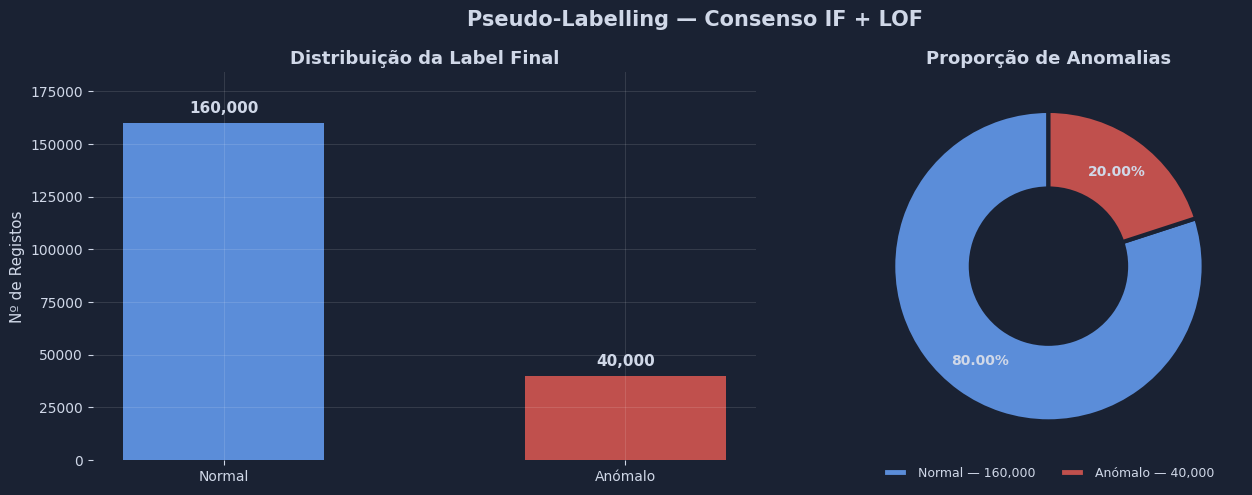

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pseudo-Labelling — Consenso IF + LOF')

contagens_pl = df_sample['pseudo_label'].value_counts().sort_index()
labels_str = ['Normal', 'Anómalo']
cores = [BLUE, RED]

# Barplot
bars = axes[0].bar(labels_str, contagens_pl.values, color=cores, width=0.5)
axes[0].set_title('Distribuição da Label Final')
axes[0].set_ylabel('Nº de Registos')
for bar, v in zip(bars, contagens_pl.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + contagens_pl.max()*0.02,
                 f'{v:,}', ha='center', va='bottom',
                 color=TEXT_COLOR, fontweight='bold', fontsize=11)
axes[0].set_ylim(0, contagens_pl.max() * 1.15)

# Donut
wedges, texts, autotexts = axes[1].pie(
    contagens_pl.values,
    colors=cores,
    autopct='%1.2f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': BG_COLOR, 'linewidth': 3, 'width': 0.5}
)
for t in autotexts:
    t.set_color(TEXT_COLOR)
    t.set_fontsize(10)
    t.set_fontweight('bold')

axes[1].set_title('Proporção de Anomalias')
axes[1].legend(
    [f'Normal — {contagens_pl[0]:,}', f'Anómalo — {contagens_pl[1]:,}'],
    loc='lower center', bbox_to_anchor=(0.5, -0.08),
    ncol=2, fontsize=9, frameon=False
)

plt.tight_layout()
plt.show()

## 18. Train/Test Split — Divisão Temporal
Divisão temporal dos dados em treino (80%) e teste (20%).
A ordenação cronológica por dia garante que o modelo é treinado no passado
e avaliado no futuro — simulando um ambiente de produção real.

In [ ]:
# Ordenar por dia cronologicamente
ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']
df_sample['day_order'] = df_sample['day'].map({d: i for i, d in enumerate(ordem_dias)})
df_sample = df_sample.sort_values('day_order').drop(columns='day_order')

# Features e label
X = df_sample[features_modelo].values
y = df_sample['pseudo_label'].values

# Time-based split 80/20
split_idx = int(len(df_sample) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Escalar features do modelo
scaler_modelo = StandardScaler()
X_train_scaled = scaler_modelo.fit_transform(X_train)
X_test_scaled  = scaler_modelo.transform(X_test)

print("=== TRAIN/TEST SPLIT ===")
print(f"  Treino : {X_train.shape[0]:,} registos ({X_train.shape[0]/len(df_sample)*100:.0f}%)")
print(f"  Teste  : {X_test.shape[0]:,} registos ({X_test.shape[0]/len(df_sample)*100:.0f}%)")
print(f"\n=== DISTRIBUIÇÃO DE CLASSES ===")
print(f"  Treino — Normal  : {(y_train==0).sum():,} | Anómalo : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print(f"  Teste  — Normal  : {(y_test==0).sum():,} | Anómalo : {(y_test==1).sum():,} ({(y_test==1).mean()*100:.2f}%)")

=== TRAIN/TEST SPLIT ===
  Treino : 160,000 registos (80%)
  Teste  : 40,000 registos (20%)

=== DISTRIBUIÇÃO DE CLASSES ===
  Treino — Normal  : 124,543 | Anómalo : 35,457 (22.16%)
  Teste  — Normal  : 35,457 | Anómalo : 4,543 (11.36%)


## 19. Distribuição de Classes — Treino vs Teste
Comparação da distribuição de classes entre o conjunto de treino e de teste.
A assimetria observada é esperada num split temporal — reflecte a distribuição
real de ataques ao longo dos dias de captura.

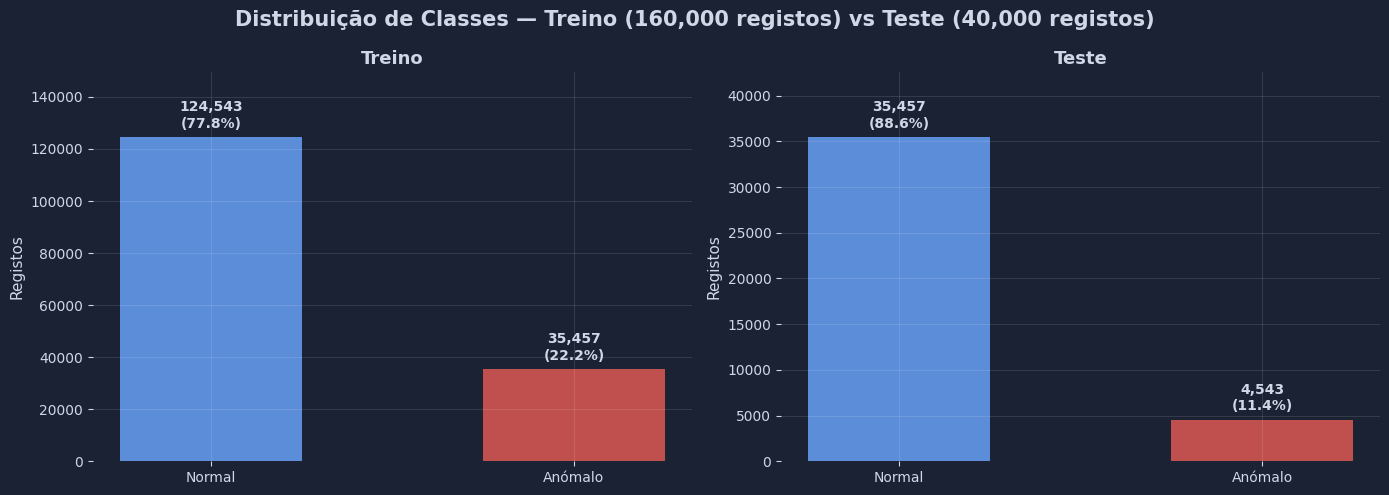

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Distribuição de Classes — Treino ({len(y_train):,} registos) vs Teste ({len(y_test):,} registos)')

for ax, y_cls, titulo in zip(axes, [y_train, y_test], ['Treino', 'Teste']):
    contagens = pd.Series(y_cls).value_counts().sort_index()
    bars = ax.bar(['Normal', 'Anómalo'], contagens.values, color=[BLUE, RED], width=0.5)
    ax.set_title(titulo)
    ax.set_ylabel('Registos')
    ax.set_ylim(0, contagens.max() * 1.2)
    for bar, v in zip(bars, contagens.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + contagens.max()*0.02,
                f'{v:,}\n({v/len(y_cls)*100:.1f}%)',
                ha='center', va='bottom',
                color=TEXT_COLOR, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 20. Modelação — Random Forest e Logistic Regression
Treino dos dois classificadores supervisionados sobre as pseudo-labels geradas.
O Random Forest captura relações não-lineares entre features, enquanto a
Logistic Regression serve de baseline linear interpretável.
Ambos os modelos são avaliados com o ground truth real do CICIDS2017.

In [29]:
# Random Forest
print("=== RANDOM FOREST ===")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
print("  ✓ Treino concluído")

# Logistic Regression
print("\n=== LOGISTIC REGRESSION ===")
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
print("  ✓ Treino concluído")

# Avaliação com pseudo-labels (y_test)
print("\n=== AVALIAÇÃO COM PSEUDO-LABELS ===")
print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Anómalo']))
print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Anómalo']))

=== RANDOM FOREST ===
  ✓ Treino concluído

=== LOGISTIC REGRESSION ===
  ✓ Treino concluído

=== AVALIAÇÃO COM PSEUDO-LABELS ===

--- Random Forest ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     35457
     Anómalo       0.94      0.89      0.92      4543

    accuracy                           0.98     40000
   macro avg       0.96      0.94      0.95     40000
weighted avg       0.98      0.98      0.98     40000


--- Logistic Regression ---
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98     35457
     Anómalo       0.84      0.81      0.83      4543

    accuracy                           0.96     40000
   macro avg       0.91      0.90      0.90     40000
weighted avg       0.96      0.96      0.96     40000



## 21. Avaliação com Ground Truth Real
Avaliação dos modelos treinados com pseudo-labels contra o ground truth real do CICIDS2017.
Esta é a métrica mais importante do pipeline — mede a capacidade do modelo de generalizar
para tráfego não visto, tendo sido treinado apenas com labels geradas automaticamente.

In [30]:
# Obter ground truth real para o conjunto de teste
y_test_real = df_sample['label'].values[split_idx:]

print("=== AVALIAÇÃO COM GROUND TRUTH REAL ===")
print("\n--- Random Forest ---")
print(classification_report(y_test_real, y_pred_rf, target_names=['Normal', 'Anómalo']))
print("\n--- Logistic Regression ---")
print(classification_report(y_test_real, y_pred_lr, target_names=['Normal', 'Anómalo']))

print("\n=== ROC-AUC ===")
print(f"  Random Forest      : {roc_auc_score(y_test_real, y_prob_rf):.4f}")
print(f"  Logistic Regression: {roc_auc_score(y_test_real, y_prob_lr):.4f}")

=== AVALIAÇÃO COM GROUND TRUTH REAL ===

--- Random Forest ---
              precision    recall  f1-score   support

      Normal       0.99      0.89      0.94     39554
     Anómalo       0.00      0.03      0.01       446

    accuracy                           0.88     40000
   macro avg       0.50      0.46      0.47     40000
weighted avg       0.98      0.88      0.93     40000


--- Logistic Regression ---
              precision    recall  f1-score   support

      Normal       0.99      0.89      0.94     39554
     Anómalo       0.00      0.03      0.01       446

    accuracy                           0.88     40000
   macro avg       0.50      0.46      0.47     40000
weighted avg       0.98      0.88      0.93     40000


=== ROC-AUC ===
  Random Forest      : 0.3516
  Logistic Regression: 0.5236


## 22. Avaliação Final — Dataset Completo
Aplicação dos modelos treinados ao dataset completo (1.58M registos) e avaliação
contra o ground truth real do CICIDS2017.
O modelo foi treinado numa amostra estratificada com pseudo-labels geradas automaticamente
e é agora avaliado sobre o volume total de tráfego — simulando um cenário de produção
onde o modelo é treinado offline e aplicado a tráfego não visto em escala real.

In [31]:
# Aplicar modelo ao dataset completo
print("=== PREPARAR DATASET COMPLETO ===")
X_full = df[features_modelo].values
X_full_scaled = scaler_modelo.transform(X_full)
y_full_real = df['label'].values

y_pred_rf_full = rf.predict(X_full_scaled)
y_pred_lr_full = lr.predict(X_full_scaled)
y_prob_rf_full = rf.predict_proba(X_full_scaled)[:, 1]
y_prob_lr_full = lr.predict_proba(X_full_scaled)[:, 1]

print(f"  Total registos : {len(y_full_real):,}")
print(f"  Anómalos reais : {y_full_real.sum():,} ({y_full_real.mean()*100:.2f}%)")

print("\n=== AVALIAÇÃO COMPLETA — RANDOM FOREST ===")
print(classification_report(y_full_real, y_pred_rf_full, target_names=['Normal', 'Anómalo']))

print("\n=== AVALIAÇÃO COMPLETA — LOGISTIC REGRESSION ===")
print(classification_report(y_full_real, y_pred_lr_full, target_names=['Normal', 'Anómalo']))

print("\n=== ROC-AUC ===")
print(f"  Random Forest       : {roc_auc_score(y_full_real, y_prob_rf_full):.4f}")
print(f"  Logistic Regression : {roc_auc_score(y_full_real, y_prob_lr_full):.4f}")

=== PREPARAR DATASET COMPLETO ===
  Total registos : 1,582,029
  Anómalos reais : 255,859 (16.17%)

=== AVALIAÇÃO COMPLETA — RANDOM FOREST ===
              precision    recall  f1-score   support

      Normal       0.93      0.90      0.91   1326170
     Anómalo       0.55      0.65      0.59    255859

    accuracy                           0.86   1582029
   macro avg       0.74      0.77      0.75   1582029
weighted avg       0.87      0.86      0.86   1582029


=== AVALIAÇÃO COMPLETA — LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

      Normal       0.93      0.89      0.91   1326170
     Anómalo       0.55      0.67      0.60    255859

    accuracy                           0.86   1582029
   macro avg       0.74      0.78      0.76   1582029
weighted avg       0.87      0.86      0.86   1582029


=== ROC-AUC ===
  Random Forest       : 0.8951
  Logistic Regression : 0.8751


## 23. Matrizes de Confusão — Comparação de Modelos
Comparação das matrizes de confusão dos dois classificadores avaliados
contra o ground truth real do dataset completo.
As células são anotadas com contagem, percentagem e classificação de severidade
operacional — perspectiva relevante para triagem em ambiente SOC.

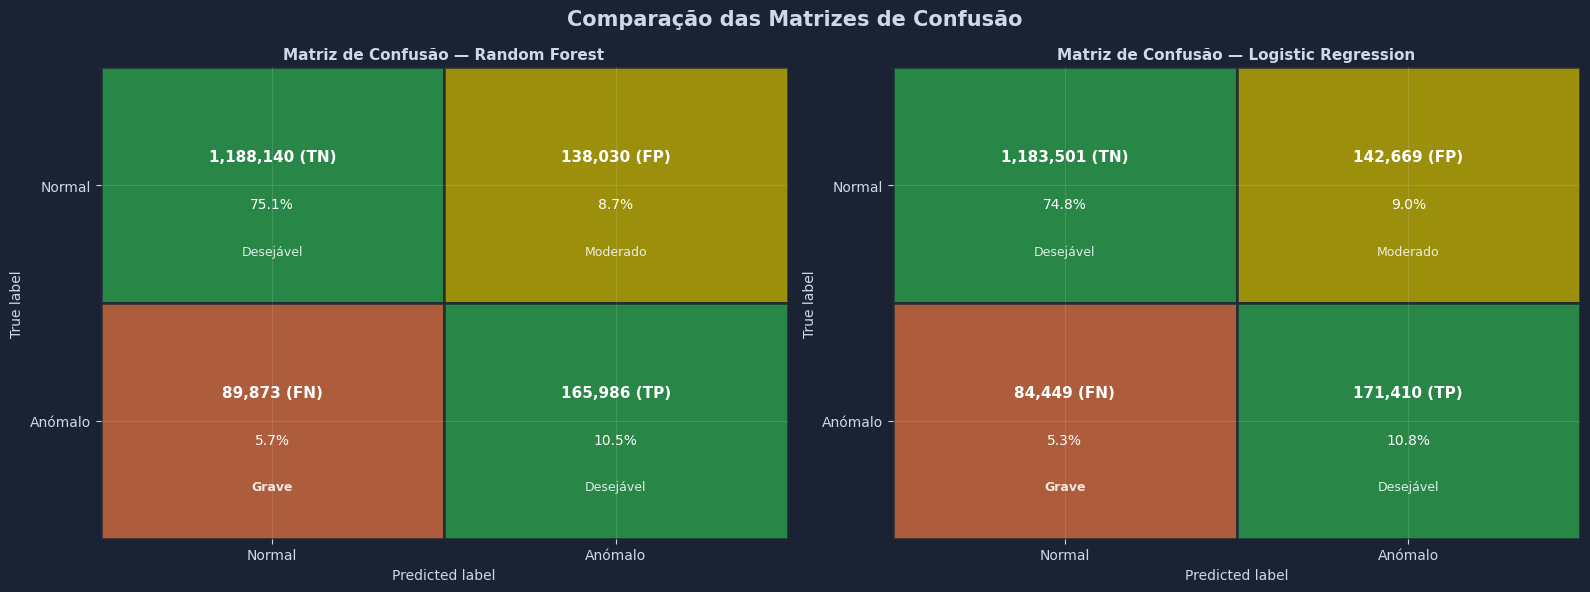

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparação das Matrizes de Confusão')

modelos = [
    ('Random Forest', y_pred_rf_full),
    ('Logistic Regression', y_pred_lr_full)
]

severidade = {
    (0,0): ('Desejável', GREEN),
    (0,1): ('Moderado', ORANGE),
    (1,0): ('Grave', '#e07040'),
    (1,1): ('Desejável', GREEN)
}

labels_cm = {
    (0,0): 'TN', (0,1): 'FP',
    (1,0): 'FN', (1,1): 'TP'
}

cores_cm = {
    (0,0): GREEN, (0,1): '#c8b400',
    (1,0): '#e07040', (1,1): GREEN
}

for ax, (nome, y_pred) in zip(axes, modelos):
    cm = confusion_matrix(y_full_real, y_pred)
    total = cm.sum()

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_facecolor(BG_COLOR)

    for i in range(2):
        for j in range(2):
            valor = cm[i, j]
            pct = valor / total * 100
            cor = cores_cm[(i, j)]
            sev_txt, _ = severidade[(i, j)]
            tipo = labels_cm[(i, j)]

            ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                         facecolor=cor, alpha=0.75, edgecolor=BG_COLOR, linewidth=2))

            ax.text(j+0.5, 1-i+0.62, f'{valor:,} ({tipo})',
                    ha='center', va='center',
                    color='white', fontsize=11, fontweight='bold')
            ax.text(j+0.5, 1-i+0.42, f'{pct:.1f}%',
                    ha='center', va='center',
                    color='white', fontsize=10)
            ax.text(j+0.5, 1-i+0.22, sev_txt,
                    ha='center', va='center',
                    color='white', fontsize=9,
                    fontweight='bold' if sev_txt == 'Grave' else 'normal',
                    alpha=0.85)

    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['Normal', 'Anómalo'], fontsize=10)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Anómalo', 'Normal'], fontsize=10)
    ax.set_xlabel('Predicted label', fontsize=10)
    ax.set_ylabel('True label', fontsize=10)
    ax.set_title(f'Matriz de Confusão — {nome}', fontsize=11)

plt.tight_layout()
plt.show()

## 24. Curva ROC — Comparação de Modelos
Comparação das curvas ROC dos dois classificadores.
A área sob a curva (AUC) mede a capacidade discriminativa do modelo
independentemente do threshold de classificação.

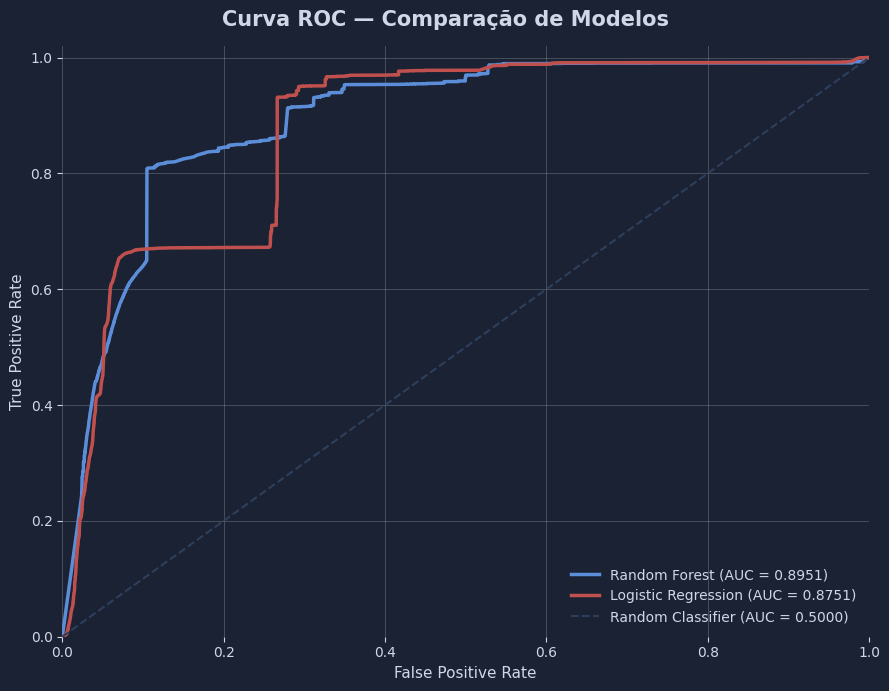

In [33]:
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Curva ROC — Comparação de Modelos')

modelos_roc = [
    ('Random Forest', y_prob_rf_full, BLUE),
    ('Logistic Regression', y_prob_lr_full, RED)
]

for nome, y_prob, cor in modelos_roc:
    fpr, tpr, _ = roc_curve(y_full_real, y_prob)
    auc = roc_auc_score(y_full_real, y_prob)
    ax.plot(fpr, tpr, color=cor, linewidth=2.5, label=f'{nome} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], color=GRID_COLOR, linewidth=1.5,
        linestyle='--', label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='both', alpha=0.2)

plt.tight_layout()
plt.show()

## 25. Feature Importance — Random Forest
Importância relativa das features do modelo supervisionado segundo o Random Forest.
Permite identificar quais as variáveis com maior poder discriminativo entre
tráfego normal e anómalo.

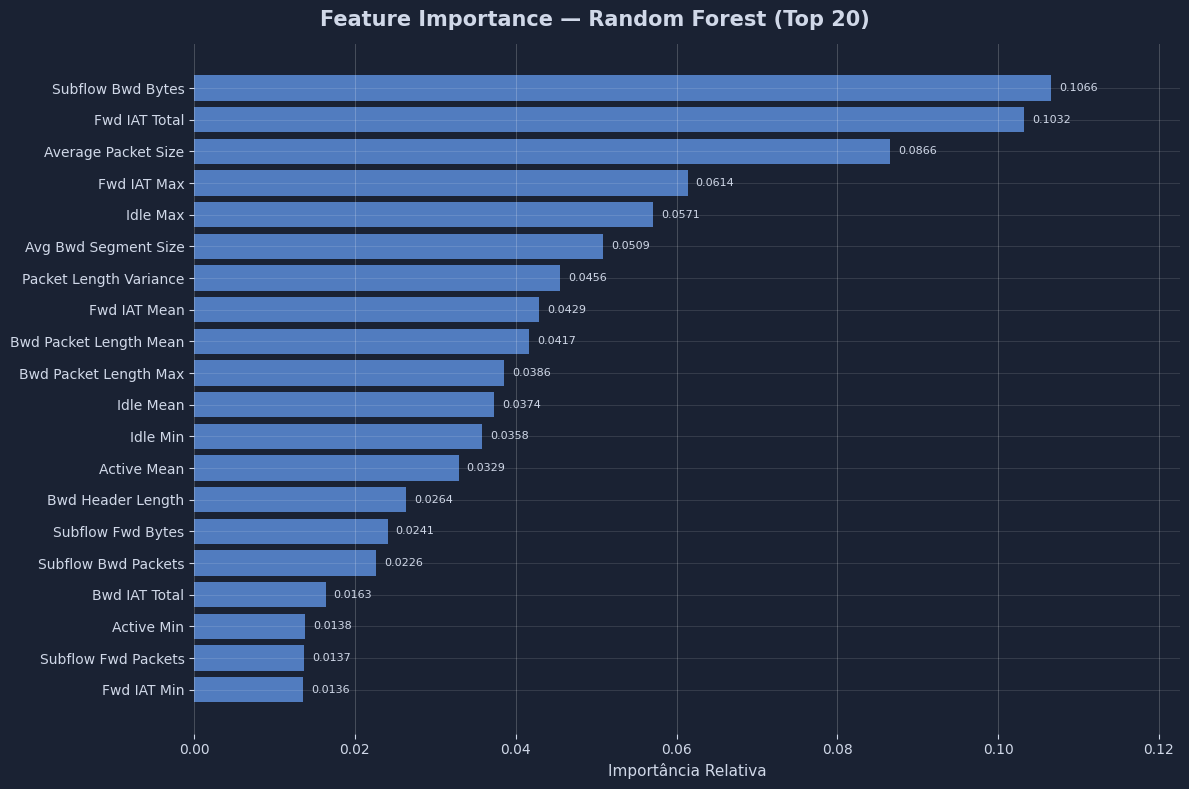

In [34]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features_sorted = [features_modelo[i] for i in indices]
importances_sorted = importances[indices]

# Top 20 features
top_n = 20
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle(f'Feature Importance — Random Forest (Top {top_n})')

bars = ax.barh(
    features_sorted[:top_n][::-1],
    importances_sorted[:top_n][::-1],
    color=BLUE, alpha=0.85
)

for bar, val in zip(bars, importances_sorted[:top_n][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8, color=TEXT_COLOR)

ax.set_xlabel('Importância Relativa')
ax.set_xlim(0, importances_sorted[0] * 1.15)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

## 26. Comparação de Modelos — Classe Anómalo
Comparação das métricas de avaliação (Precision, Recall, F1-score e ROC-AUC)
entre o Random Forest e a Logistic Regression para a classe anómala.

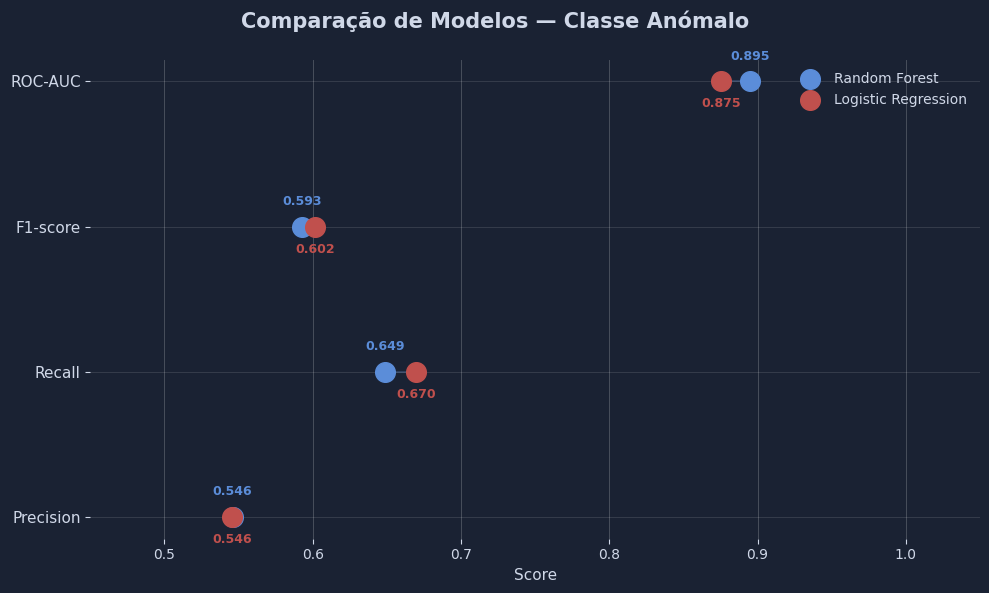

In [38]:
metricas_nomes = ['Precision', 'Recall', 'F1-score', 'ROC-AUC']
valores_rf = [
    precision_score(y_full_real, y_pred_rf_full),
    recall_score(y_full_real, y_pred_rf_full),
    f1_score(y_full_real, y_pred_rf_full),
    roc_auc_score(y_full_real, y_prob_rf_full)
]
valores_lr = [
    precision_score(y_full_real, y_pred_lr_full),
    recall_score(y_full_real, y_pred_lr_full),
    f1_score(y_full_real, y_pred_lr_full),
    roc_auc_score(y_full_real, y_prob_lr_full)
]

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Comparação de Modelos — Classe Anómalo')

y_pos = np.arange(len(metricas_nomes))

for i, (metrica, vrf, vlr) in enumerate(zip(metricas_nomes, valores_rf, valores_lr)):
    ax.plot([vrf, vlr], [i, i], color=GRID_COLOR, linewidth=1.5, zorder=1)
    ax.scatter(vrf, i, color=BLUE, s=200, zorder=2, label='Random Forest' if i == 0 else '')
    ax.scatter(vlr, i, color=RED, s=200, zorder=2, label='Logistic Regression' if i == 0 else '')
    ax.text(vrf, i + 0.15, f'{vrf:.3f}', ha='center', color=BLUE, fontsize=9, fontweight='bold')
    ax.text(vlr, i - 0.18, f'{vlr:.3f}', ha='center', color=RED, fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(metricas_nomes, fontsize=11)
ax.set_xlabel('Score')
ax.set_xlim(0.45, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

## 27. Diagrama de Venn — Anomalias Detectadas
Comparação das anomalias detectadas pelo Random Forest e pela Logistic Regression.
Mostra a intersecção e as detecções exclusivas de cada modelo — útil para perceber
o grau de concordância entre os dois classificadores e identificar casos ambíguos.

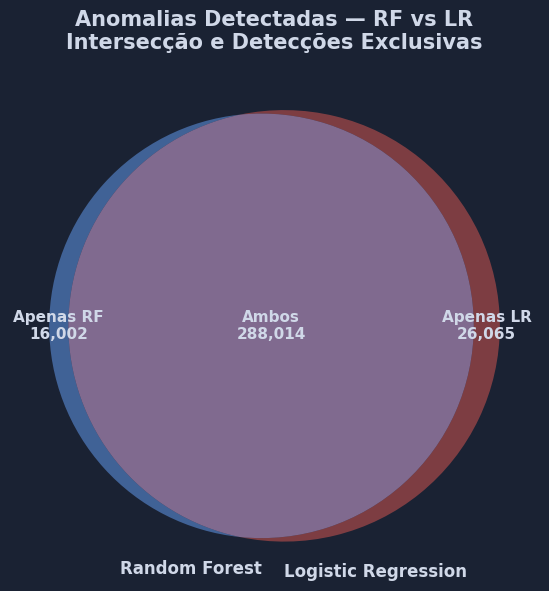

In [39]:
set_rf = set(np.where(y_pred_rf_full == 1)[0])
set_lr = set(np.where(y_pred_lr_full == 1)[0])

only_rf = len(set_rf - set_lr)
only_lr = len(set_lr - set_rf)
both    = len(set_rf & set_lr)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Anomalias Detectadas — RF vs LR\nIntersecção e Detecções Exclusivas')
ax.set_facecolor(BG_COLOR)
ax.axis('off')

v = venn2(subsets=(only_rf, only_lr, both), ax=ax,
          set_labels=('Random Forest', 'Logistic Regression'),
          set_colors=(BLUE, RED), alpha=0.6)

for text in v.set_labels:
    text.set_color(TEXT_COLOR)
    text.set_fontsize(12)
    text.set_fontweight('bold')

for text in v.subset_labels:
    if text:
        text.set_color(TEXT_COLOR)
        text.set_fontsize(11)
        text.set_fontweight('bold')

v.get_label_by_id('10').set_text(f'Apenas RF\n{only_rf:,}')
v.get_label_by_id('01').set_text(f'Apenas LR\n{only_lr:,}')
v.get_label_by_id('11').set_text(f'Ambos\n{both:,}')

plt.tight_layout()
plt.show()

## 28. Top Portos com Mais Anomalias
Identificação dos portos de destino com maior volume de tráfego anómalo detectado.
Permite identificar os serviços de rede mais visados por ataques —
informação operacionalmente relevante para priorização de regras de firewall e SIEM.

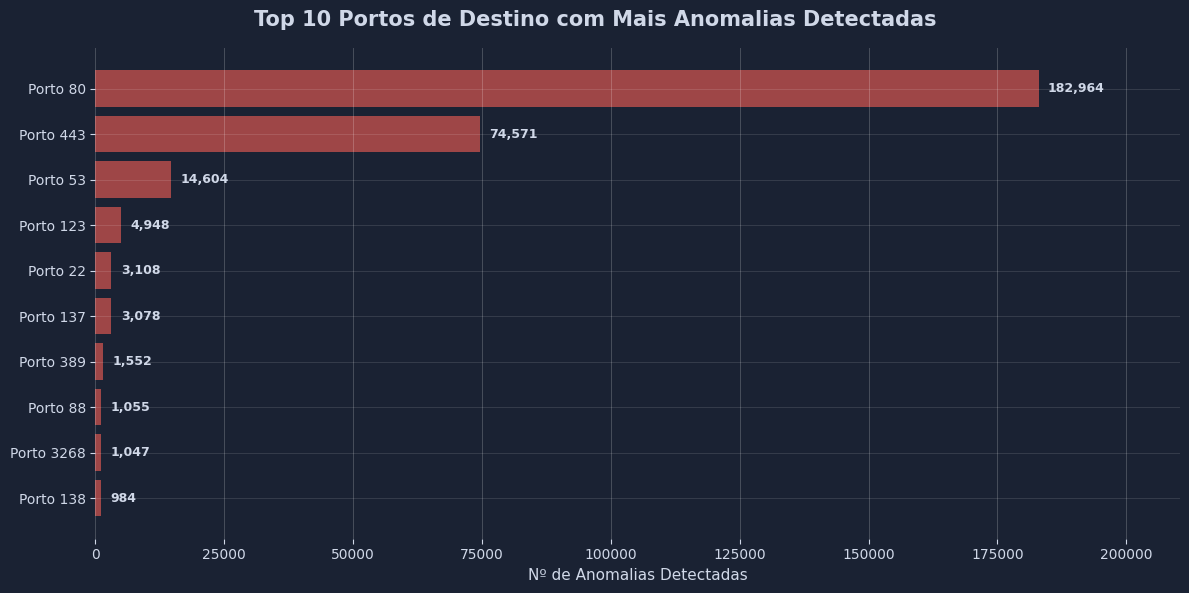

In [41]:
df['y_pred_rf'] = y_pred_rf_full

top_n = 10
anomalos_porto = (df[df['y_pred_rf'] == 1]
                  .groupby('Destination Port')
                  .size()
                  .sort_values(ascending=False)
                  .head(top_n))

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle(f'Top {top_n} Portos de Destino com Mais Anomalias Detectadas')

bars = ax.barh(
    [f'Porto {p}' for p in anomalos_porto.index[::-1]],
    anomalos_porto.values[::-1],
    color=RED, alpha=0.80
)

for bar, val in zip(bars, anomalos_porto.values[::-1]):
    ax.text(bar.get_width() + anomalos_porto.max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9,
            color=TEXT_COLOR, fontweight='bold')

ax.set_xlabel('Nº de Anomalias Detectadas')
ax.set_xlim(0, anomalos_porto.max() * 1.15)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

## 29. Previsão de Anomalias — Simulação de Monitorização Contínua
Aplicação do modelo treinado ao dataset completo para simular monitorização contínua.
Mostra a evolução do volume e proporção de anomalias detectadas por dia de captura —
demonstrando a capacidade do pipeline de operar em escala real e gerar alertas accionáveis.

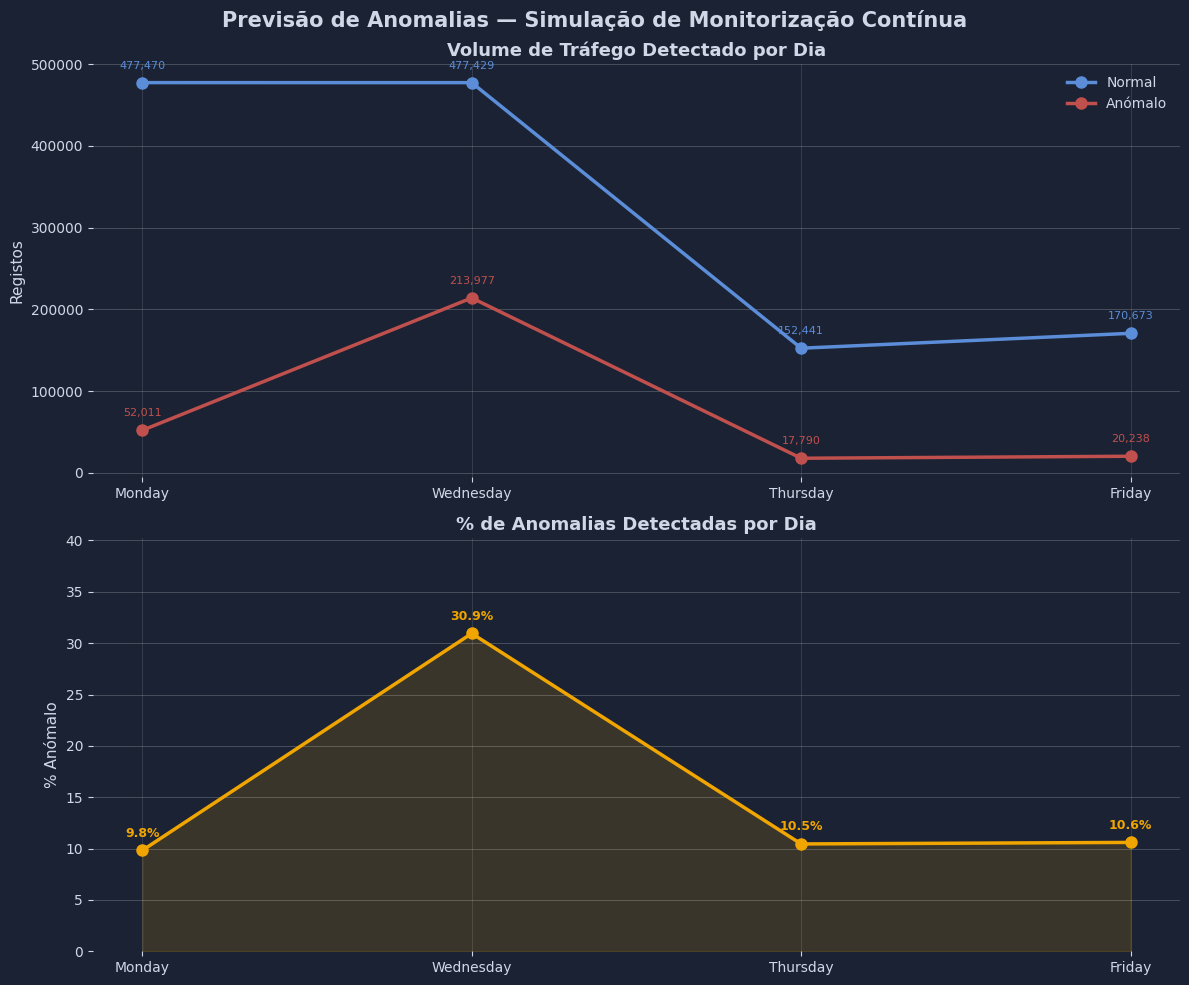

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Previsão de Anomalias — Simulação de Monitorização Contínua')

ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']

# Volume absoluto por dia
volume = df.groupby(['day', 'y_pred_rf']).size().unstack(fill_value=0)
volume = volume.reindex(ordem_dias)
volume.columns = ['Normal', 'Anómalo']

axes[0].plot(ordem_dias, volume['Normal'], color=BLUE, linewidth=2.5,
             marker='o', markersize=8, label='Normal')
axes[0].plot(ordem_dias, volume['Anómalo'], color=RED, linewidth=2.5,
             marker='o', markersize=8, label='Anómalo')

for dia in ordem_dias:
    axes[0].annotate(f"{volume['Normal'][dia]:,}",
                     (dia, volume['Normal'][dia]),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=BLUE, fontsize=8)
    axes[0].annotate(f"{volume['Anómalo'][dia]:,}",
                     (dia, volume['Anómalo'][dia]),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=RED, fontsize=8)

axes[0].set_title('Volume de Tráfego Detectado por Dia')
axes[0].set_ylabel('Registos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.2)

# Proporção de anomalias por dia
proporcao = volume['Anómalo'] / (volume['Normal'] + volume['Anómalo']) * 100

axes[1].plot(ordem_dias, proporcao.values, color=ORANGE, linewidth=2.5,
             marker='o', markersize=8)
axes[1].fill_between(ordem_dias, proporcao.values, alpha=0.15, color=ORANGE)

for dia, val in zip(ordem_dias, proporcao.values):
    axes[1].annotate(f'{val:.1f}%', (dia, val),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', color=ORANGE, fontsize=9, fontweight='bold')

axes[1].set_title('% de Anomalias Detectadas por Dia')
axes[1].set_ylabel('% Anómalo')
axes[1].set_ylim(0, proporcao.max() * 1.3)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 30. Simulação de Deployment — Previsão em Dados Futuros
Simulação de um cenário de produção onde o modelo treinado é aplicado a tráfego
não visto — os últimos 20% do dataset ordenado cronologicamente.
Para cada fluxo de rede o modelo devolve uma probabilidade de anomalia,
permitindo triagem por nível de risco antes de confirmação humana.

=== DISTRIBUIÇÃO DE RISCO — TRÁFEGO FUTURO ===
nivel_risco
Baixo      268784
Médio       15817
Alto         2309
Crítico     29496
Name: count, dtype: int64

  Total fluxos analisados : 316,406
  Fluxos de alto risco    : 31,805 (10.05%)
  Fluxos críticos         : 29,496 (9.32%)


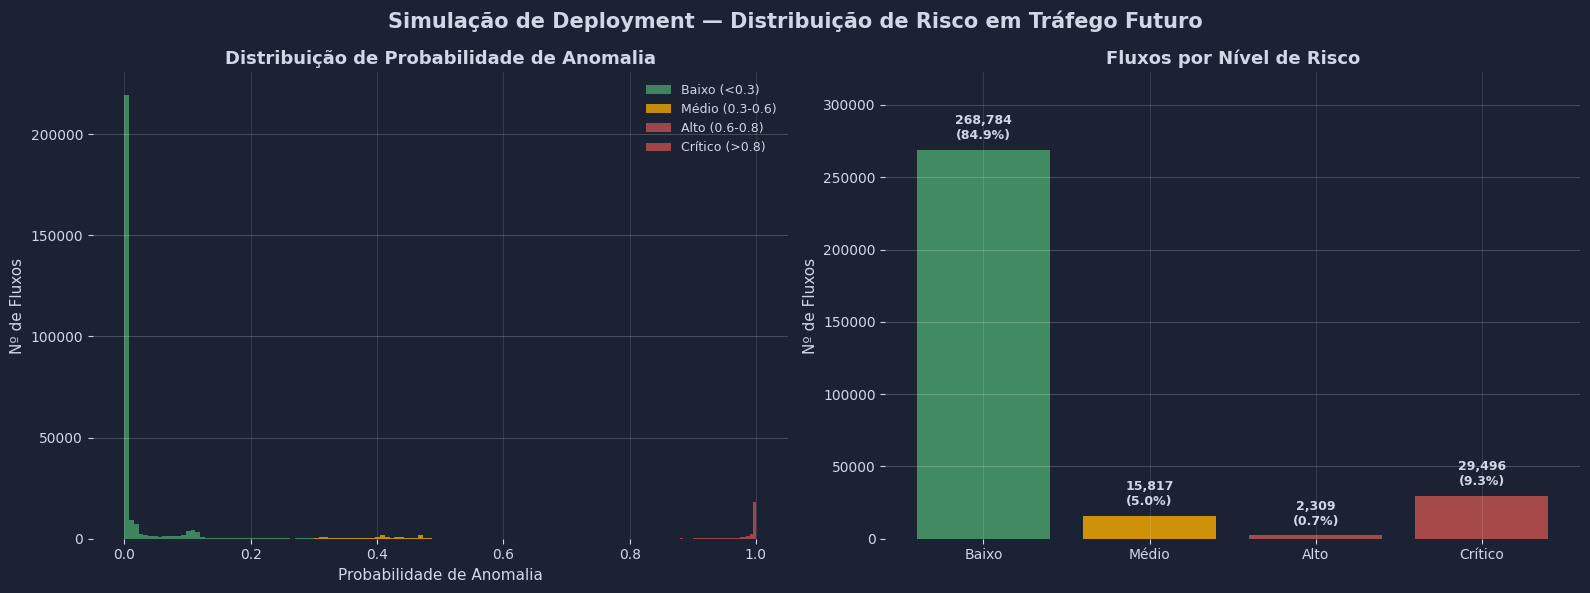

In [43]:
# Ordenar dataset completo cronologicamente
ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']
df['day_order'] = df['day'].map({d: i for i, d in enumerate(ordem_dias)})
df = df.sort_values('day_order').reset_index(drop=True)

# Últimos 20% — "tráfego futuro"
split_full = int(len(df) * 0.80)
df_futuro = df.iloc[split_full:].copy()

X_futuro = df_futuro[features_modelo].values
X_futuro_scaled = scaler_modelo.transform(X_futuro)

# Probabilidades de anomalia
prob_anomalia = rf.predict_proba(X_futuro_scaled)[:, 1]
df_futuro['prob_anomalia'] = prob_anomalia
df_futuro['nivel_risco'] = pd.cut(
    prob_anomalia,
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Baixo', 'Médio', 'Alto', 'Crítico']
)

print("=== DISTRIBUIÇÃO DE RISCO — TRÁFEGO FUTURO ===")
print(df_futuro['nivel_risco'].value_counts().sort_index())
print(f"\n  Total fluxos analisados : {len(df_futuro):,}")
print(f"  Fluxos de alto risco    : {(prob_anomalia >= 0.6).sum():,} ({(prob_anomalia >= 0.6).mean()*100:.2f}%)")
print(f"  Fluxos críticos         : {(prob_anomalia >= 0.8).sum():,} ({(prob_anomalia >= 0.8).mean()*100:.2f}%)")

# Gráfico de distribuição de probabilidades
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Simulação de Deployment — Distribuição de Risco em Tráfego Futuro')

# Histograma de probabilidades
axes[0].hist(prob_anomalia[prob_anomalia < 0.3], bins=40,
             color='#4a9e6b', alpha=0.8, label='Baixo (<0.3)')
axes[0].hist(prob_anomalia[(prob_anomalia >= 0.3) & (prob_anomalia < 0.6)], bins=40,
             color=ORANGE, alpha=0.8, label='Médio (0.3-0.6)')
axes[0].hist(prob_anomalia[(prob_anomalia >= 0.6) & (prob_anomalia < 0.8)], bins=40,
             color='#c05050', alpha=0.8, label='Alto (0.6-0.8)')
axes[0].hist(prob_anomalia[prob_anomalia >= 0.8], bins=40,
             color=RED, alpha=0.8, label='Crítico (>0.8)')
axes[0].set_title('Distribuição de Probabilidade de Anomalia')
axes[0].set_xlabel('Probabilidade de Anomalia')
axes[0].set_ylabel('Nº de Fluxos')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.2)

# Barplot de níveis de risco
contagens_risco = df_futuro['nivel_risco'].value_counts().sort_index()
cores_risco = ['#4a9e6b', ORANGE, '#c05050', RED]
bars = axes[1].bar(contagens_risco.index, contagens_risco.values,
                   color=cores_risco, alpha=0.85)
axes[1].set_title('Fluxos por Nível de Risco')
axes[1].set_ylabel('Nº de Fluxos')
for bar, val in zip(bars, contagens_risco.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + contagens_risco.max() * 0.02,
                 f'{val:,}\n({val/len(df_futuro)*100:.1f}%)',
                 ha='center', va='bottom',
                 color=TEXT_COLOR, fontsize=9, fontweight='bold')
axes[1].set_ylim(0, contagens_risco.max() * 1.2)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 31. Tendência de Risco — Projecção Temporal
Análise da tendência de anomalias detectadas por dia e projecção para o período seguinte.
Permite antecipar o nível de risco esperado com base no comportamento histórico observado.

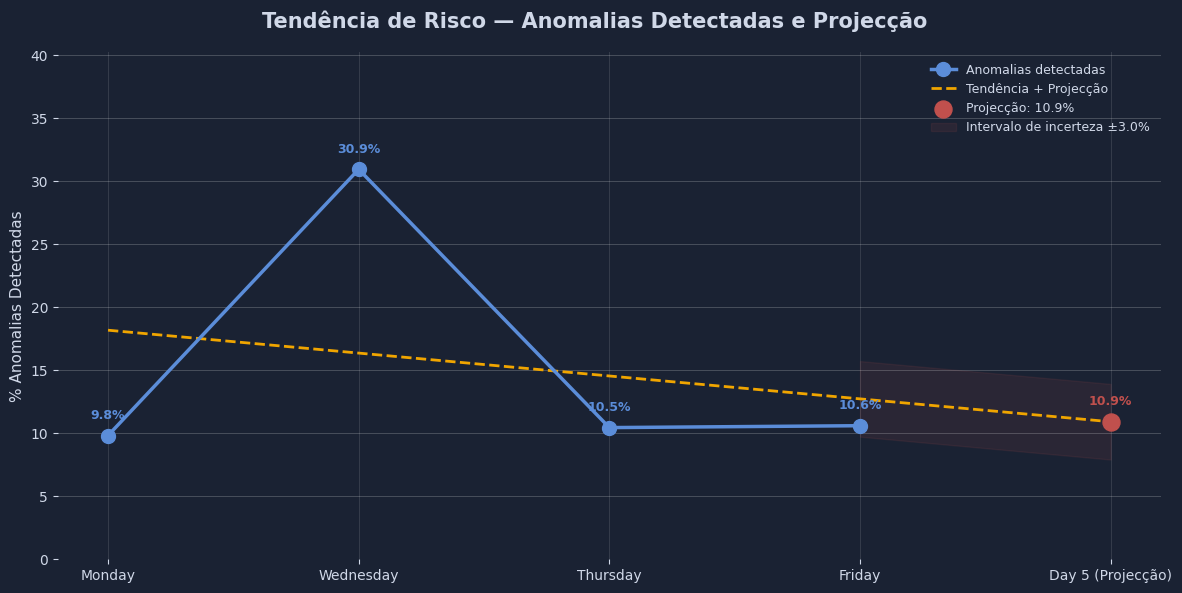

In [45]:
ordem_dias = ['Monday', 'Wednesday', 'Thursday', 'Friday']
proporcao_dia = (df.groupby('day')['y_pred_rf']
                 .mean() * 100).reindex(ordem_dias)

x_num = np.arange(len(ordem_dias))

# Ajuste linear
coef = np.polyfit(x_num, proporcao_dia.values, 1)
tendencia = np.poly1d(coef)

# Projecção para o dia seguinte
x_proj = np.append(x_num, len(ordem_dias))
y_proj = tendencia(x_proj)
dias_proj = ordem_dias + ['Day 5 (Projecção)']

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Tendência de Risco — Anomalias Detectadas e Projecção')

# Linha real
ax.plot(ordem_dias, proporcao_dia.values, color=BLUE, linewidth=2.5,
        marker='o', markersize=10, label='Anomalias detectadas', zorder=3)

# Linha de tendência + projecção
ax.plot(dias_proj, y_proj, color=ORANGE, linewidth=2,
        linestyle='--', label='Tendência + Projecção', zorder=2)

# Ponto de projecção
ax.scatter(['Day 5 (Projecção)'], [y_proj[-1]], color=RED,
           s=150, zorder=4, label=f'Projecção: {y_proj[-1]:.1f}%')

# Área de incerteza
margem = 3.0
ax.fill_between(dias_proj[-2:],
                [y_proj[-2] - margem, y_proj[-1] - margem],
                [y_proj[-2] + margem, y_proj[-1] + margem],
                color=RED, alpha=0.1, label=f'Intervalo de incerteza ±{margem}%')

# Anotações
for dia, val in zip(ordem_dias, proporcao_dia.values):
    ax.annotate(f'{val:.1f}%', (dia, val),
                textcoords='offset points', xytext=(0, 12),
                ha='center', color=BLUE, fontsize=9, fontweight='bold')

ax.annotate(f'{y_proj[-1]:.1f}%', ('Day 5 (Projecção)', y_proj[-1]),
            textcoords='offset points', xytext=(0, 12),
            ha='center', color=RED, fontsize=9, fontweight='bold')

ax.set_ylabel('% Anomalias Detectadas')
ax.set_ylim(0, max(proporcao_dia.max(), y_proj.max()) * 1.3)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 32. Conclusões

### Síntese do Pipeline

Este projecto implementou um pipeline completo de detecção de anomalias em tráfego
de rede sobre o dataset CICIDS2017, combinando técnicas não supervisionadas de
pseudo-labelling com classificação supervisionada avaliada contra ground truth real.

### Resultados Principais

O consenso ponderado entre **Isolation Forest** e **Local Outlier Factor** gerou
pseudo-labels com F1 de 0.60 e concordância de 85.46% com o ground truth real —
demonstrando que é possível gerar labels de qualidade aceitável sem supervisão humana.

Os dois classificadores supervisionados treinados sobre essas pseudo-labels e avaliados
no dataset completo (1.58M registos) produziram resultados sólidos:

| Métrica | Random Forest | Logistic Regression |
|---|---|---|
| Precision (Anómalo) | 55% | 55% |
| Recall (Anómalo) | 65% | 67% |
| F1-score (Anómalo) | 0.59 | 0.60 |
| ROC-AUC | 0.8951 | 0.8751 |

A **Logistic Regression** apresentou F1 ligeiramente superior ao Random Forest na
classe anómala — sugerindo que a separação entre tráfego normal e anómalo nas
features estruturais de sessão TCP tem uma componente linear relevante.

O **ROC-AUC de 0.89** do Random Forest é particularmente significativo dado que o
modelo foi treinado exclusivamente com pseudo-labels geradas automaticamente, sem
acesso ao ground truth durante o treino.

### Relevância Operacional

A análise dos portos de destino com mais anomalias detectadas fornece informação
accionável para equipas SOC — permitindo priorizar regras de firewall e correlações
no SIEM com base em evidência quantitativa.

A simulação de deployment demonstrou que o pipeline é capaz de classificar tráfego
não visto em escala real, atribuindo níveis de risco (Baixo / Médio / Alto / Crítico)
a cada fluxo de rede — funcionalidade directamente aplicável em ambiente de produção.

A análise de tendência temporal sugere que a proporção de anomalias detectadas
apresenta variação significativa entre dias de captura, o que reforça a necessidade
de monitorização contínua em vez de análise pontual.

### Limitações

- O dataset CICIDS2017 foi gerado em ambiente laboratorial controlado — a
  generalização para tráfego de produção real requer validação adicional.
- A ausência de timestamps granulares limitou a análise temporal a granularidade diária.
- O pseudo-labelling com Recall de 67% implica que aproximadamente 1 em cada 3
  ataques reais não foi capturado durante o treino — margem de melhoria relevante
  para iterações futuras.
- O pipeline actual opera em modo batch — a implementação em tempo real requereria
  integração com um sistema de ingestão de dados em stream (ex: Kafka, Splunk).

### Trabalho Futuro

- Testar com dados de tráfego real de produção para validar generalização
- Integrar com pipeline de ingestão em tempo real via Kafka ou Splunk
- Explorar modelos de deep learning (Autoencoder, LSTM) para detecção de anomalias
  temporais com granularidade sub-segundo
- Implementar retreino automático do modelo com novos dados rotulados por analistas SOC